In [108]:
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path

In [109]:
log_dir = Path("/Users/s3002149/Library/CloudStorage/OneDrive-UniversityofEdinburgh/Daten SU(2) Pure Gauge/raw_data/logs")
logs = list(log_dir.glob("*.log"))

for log in logs:
    print(log.name)

L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta2_md10_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md10_trajL2_traj100_ckpt5.log
L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta2_md10_trajL0.5_traj100_ckpt5.log
L8x8x8x8_beta2_md5_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md10_trajL0.5_traj1000_ckpt5.log
L8x8x8x8_beta2_md40_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta6_md10_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md20_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md8_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta6_md10_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta4_md10_trajL1.0_traj1000_ckpt5.log
L12x12x12x12_beta5.6_md20_trajL1.0_traj2_ckpt5.log
L8x8x8x8_beta2_md10_trajL2_traj1000_ckpt5.log
L8x8x8x8_beta8_md10_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md20_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta2_md8_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta8_md10_trajL1.0_traj100_ckpt5.log
L8x8x8

In [110]:
import re
from pathlib import Path

def parse_log_name(path):

    name = path.name

    result = {}

    m = re.search(r"L(\d+x\d+x\d+x\d+)", name)
    if m:
        result["lattice"] = m.group(1)

    m = re.search(r"_beta([\d.]+)", name)
    if m:
        result["beta"] = float(m.group(1))

    m = re.search(r"_md(\d+)", name)
    if m:
        result["mdsteps"] = int(m.group(1))

    m = re.search(r"_trajL([\d.]+)", name)
    if m:
        result["trajL"] = float(m.group(1))

    m = re.search(r"_traj(\d+)", name)
    if m:
        result["trajectories"] = int(m.group(1))

    m = re.search(r"_ckpt(\d+)", name)
    if m:
        result["checkpoint"] = int(m.group(1))

    return result

In [111]:
for log in logs:
    print(parse_log_name(log))

{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 1.25, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 5, 'trajL': 1.0, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 4.0, 'mdsteps': 10, 'trajL': 1.0, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 1.0, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 2.0, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 1.0, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 0.5, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 5, 'trajL': 1.0, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 0.5, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 40, 'trajL': 1.0, 'traj

In [112]:
import pandas as pd

data = []

for log in logs:
    row = parse_log_name(log)
    row["file"] = log
    data.append(row)

df = pd.DataFrame(data)

df

,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,8x8x8x8,2.0,10,1.25,1000,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
1,8x8x8x8,2.0,5,1.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
2,8x8x8x8,4.0,10,1.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
3,8x8x8x8,2.0,10,1.00,1000,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
4,8x8x8x8,2.0,10,2.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
5,8x8x8x8,2.0,10,1.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
6,8x8x8x8,2.0,10,0.50,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
7,8x8x8x8,2.0,5,1.00,1000,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
8,8x8x8x8,2.0,10,0.50,1000,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
9,8x8x8x8,2.0,40,1.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...


In [113]:
def parse_plaquette(logfile):

    data = []

    with open(logfile) as f:
        for line in f:

            m = re.search(
                r"Plaquette:\s+\[\s*(\d+)\s*\]\s+([\d\.Ee+-]+)",
                line
            )

            if m:
                data.append(
                    {
                        "trajectory": int(m.group(1)),
                        "plaquette": float(m.group(2))
                    }
                )

    df = pd.DataFrame(data)

    # doppelte MPI-Ausgaben entfernen
    df = df.drop_duplicates(
        subset=["trajectory", "plaquette"]
    )

    return df.to_dict("records")

In [114]:
measurements = []

for log in logs:

    # Parameter aus Dateinamen
    params = parse_log_name(log)

    # Plaquette Werte aus Log
    plaqs = parse_plaquette(log)

    for p in plaqs:
        p.update(params)
        p["file"] = log.name
        measurements.append(p)


df = pd.DataFrame(measurements)

df.head()

,trajectory,plaquette,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,1,0.282783,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
1,2,0.379957,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
2,3,0.432218,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
3,4,0.458476,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
4,5,0.476369,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log


In [115]:
#df_hdf5 = df.to_hdf("/home/max/PhD/programs/su2/pure_gauge/data/plaquette_measurements.h5", key="plaquette", mode="w") #zu raw_data hinzufügen

In [116]:

df_beta_scan = df[(df.mdsteps == 10) &(df.trajL == 1.0)]
df_beta_scan = df_beta_scan[df_beta_scan.beta != 5.6] # 5.6 run ignorieren

df_mdsteps_scan = df[(df.beta == 2) & (df.trajL == 1.0) & (df.mdsteps != 40)]
df_trajL_scan = df[(df.beta == 2) & (df.mdsteps == 10)]

df_traj100 = df_beta_scan[df_beta_scan.trajectories==100]
df_traj1000 = df_beta_scan[df_beta_scan.trajectories==1000]

df_mdsteps_traj100 = df_mdsteps_scan[df_mdsteps_scan.trajectories == 100]
df_mdsteps_traj1000 = df_mdsteps_scan[df_mdsteps_scan.trajectories == 1000]

df_trajL_traj100 = df_trajL_scan[df_trajL_scan.trajectories == 100]
df_trajL_traj1000 = df_trajL_scan[df_trajL_scan.trajectories == 1000]

In [117]:
#Plotfunktion plaquette vs trajectories für alle beta
def plot_plaquette_history(df_plot, title=None):
    
    plt.figure(figsize=(8,5), layout="constrained")

    for beta in sorted(df_plot.beta.unique()):
        subset = (
            df_plot[df_plot.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.plaquette,
            ".",
            label=fr"$\beta={beta}$"
        )

    plt.xlabel("trajectory")
    plt.ylabel("plaquette")
    plt.legend()
    plt.grid()

    if title:
        plt.title(title)

    plt.show()

In [118]:
#df_traj100.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/plaquette_measurements_traj100.csv", index=False)
#df_traj1000.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/plaquette_measurements_traj1000.csv", index=False)


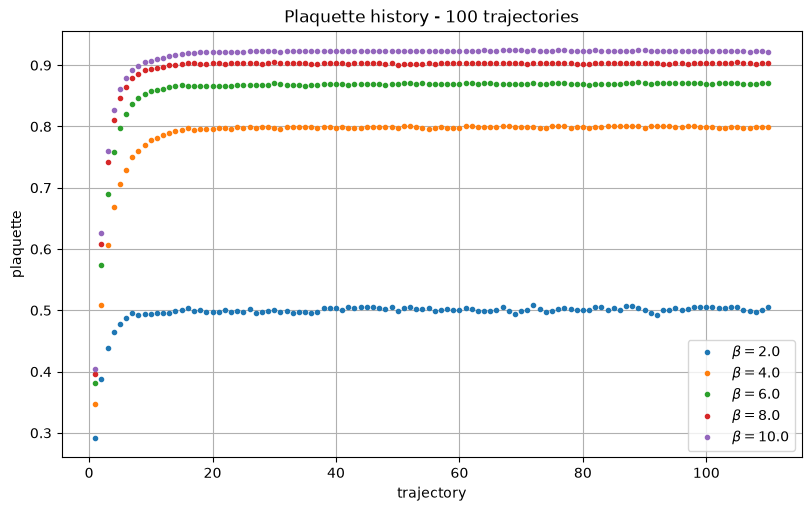

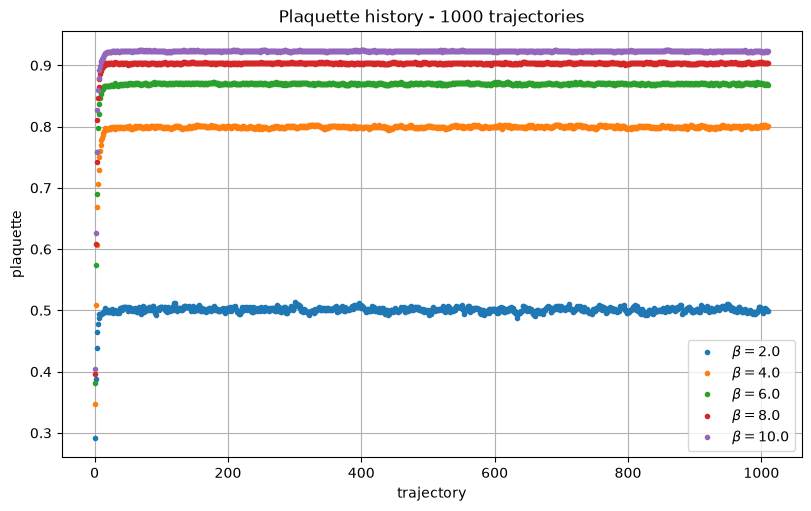

In [119]:
plot_plaquette_history(df_traj100, "Plaquette history - 100 trajectories") #namen der spalten anpassen
plot_plaquette_history(df_traj1000, "Plaquette history - 1000 trajectories")
    

In [120]:
df_phys_traj100 = df_traj100[df_traj100.trajectory > 20] #thermalisieren abschneiden beta scan
df_phys_traj1000 = df_traj1000[df_traj1000.trajectory > 100] #beta scan

df_phys_mdsteps_traj100 = df_mdsteps_traj100[df_mdsteps_traj100.trajectory > 20]
df_phys_mdsteps_traj1000 = df_mdsteps_traj1000[df_mdsteps_traj1000.trajectory > 100]

df_phys_trajL_traj100 = df_trajL_traj100[df_trajL_traj100.trajectory > 20]
df_phys_trajL_traj1000 = df_trajL_traj1000[df_trajL_traj1000.trajectory > 100]

In [121]:
def plot_hist_plaquette(df, beta, bins=30):

    values = df["plaquette"]

    mean = values.mean()
    std = values.std()

    plt.figure(figsize=(8,5))

    plt.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.7,
        rwidth=0.5
    )

    plt.axvline(
        mean,
        linestyle="--",
        label=fr"$\langle P\rangle={mean:.5f}$"
    )

    plt.xlabel(r"$P$")
    plt.ylabel("Probability density")
    plt.title(fr"Plaquette distribution $\beta={beta}$, x axis range 5$\sigma$")
    plt.legend()
    plt.grid()

    plt.xlim(
        mean - 5*std,
        mean + 5*std
    )

    plt.show()

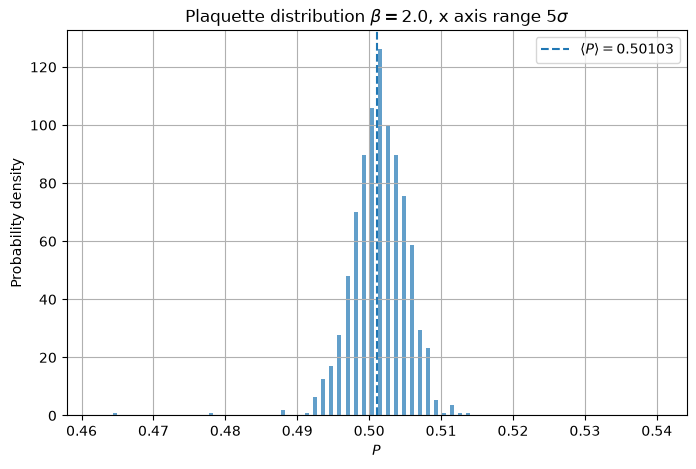

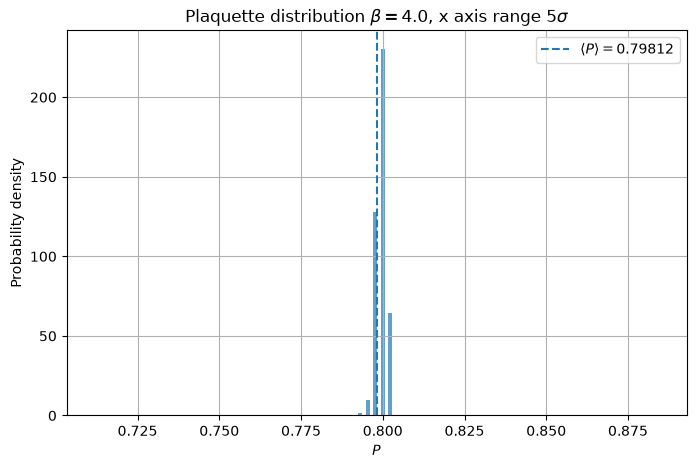

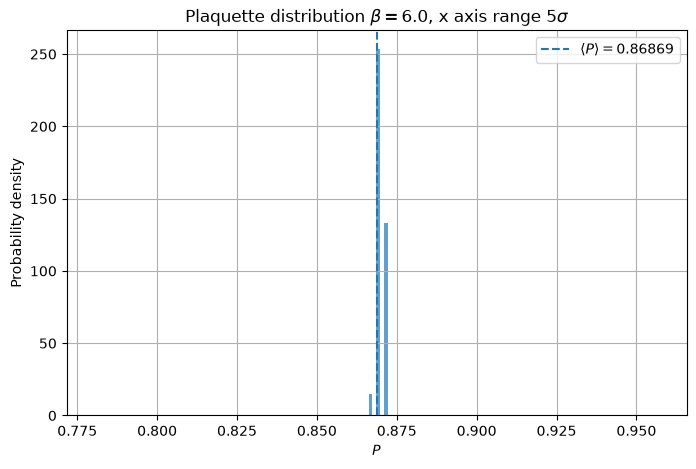

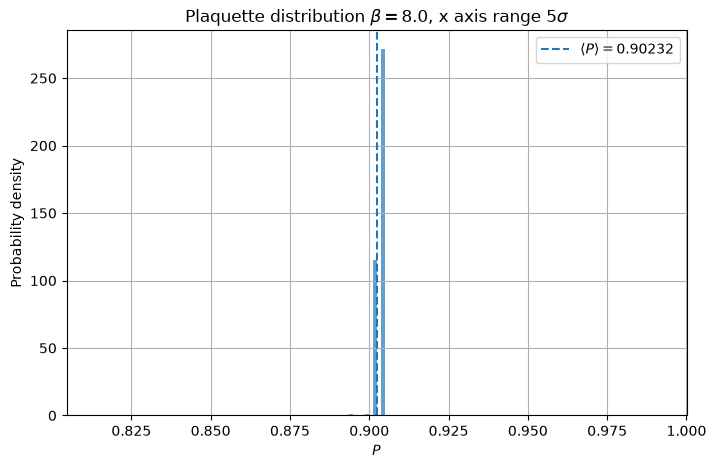

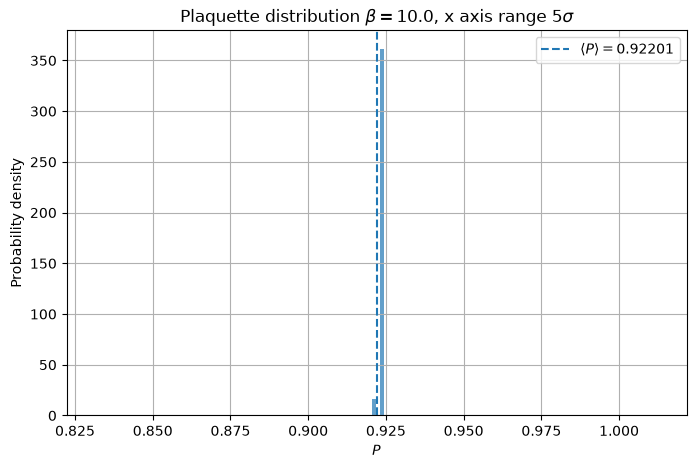

In [122]:
for beta in sorted(df_traj1000.beta.unique()):
    
    subset = df_traj1000[
        df_traj1000.beta == beta
    ]
    
    plot_hist_plaquette(
        subset,
        beta,
        bins=200
    )

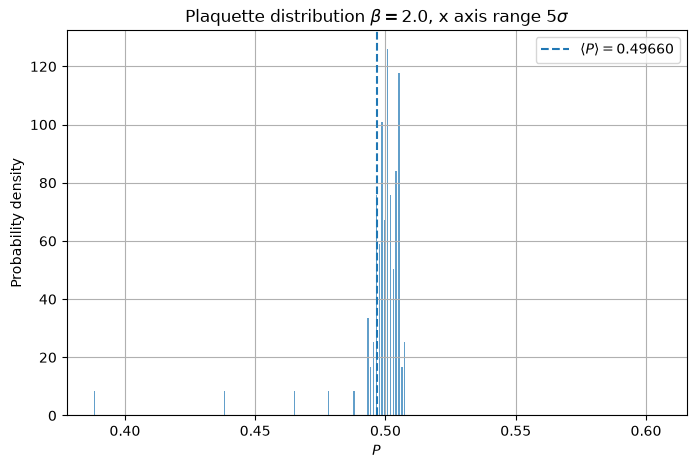

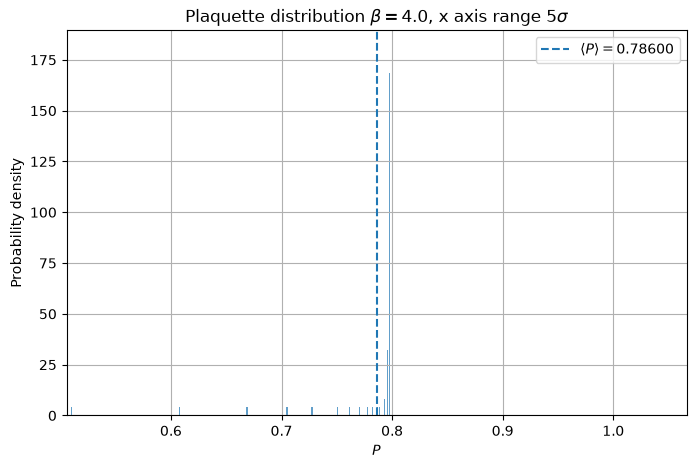

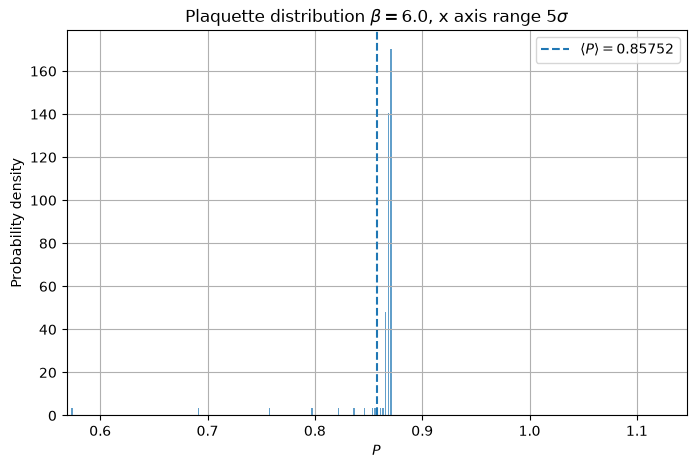

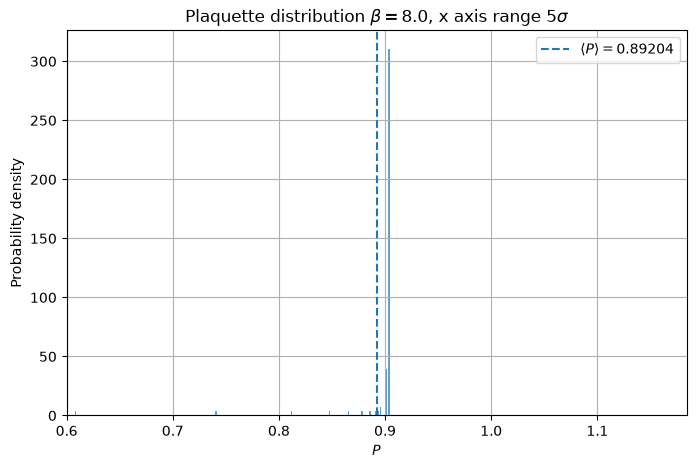

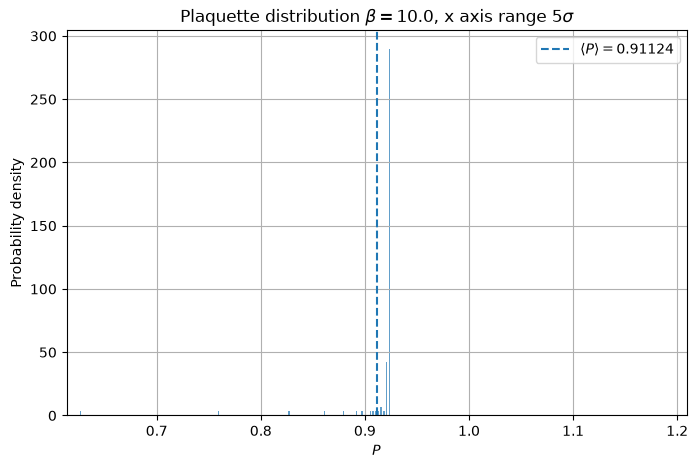

In [123]:
for beta in sorted(df_traj100.beta.unique()):
    
    subset = df_traj100[
        df_traj100.beta == beta
    ]
    
    plot_hist_plaquette(
        subset,
        beta,
        bins=200
    )

In [124]:
def plaq_stats(df):

    stats = (
        df
        .groupby("beta")
        .plaquette
        .agg(
            N="count",
            mean="mean",
            std="std"
        ).sort_index()
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats

In [125]:
df_beta2_traj100= df_phys_traj100[df_phys_traj100['beta'] == 2]
df_beta4_traj100= df_phys_traj100[df_phys_traj100['beta'] == 4]
df_beta6_traj100= df_phys_traj100[df_phys_traj100['beta'] == 6]
df_beta8_traj100= df_phys_traj100[df_phys_traj100['beta'] == 8]
df_beta10_traj100= df_phys_traj100[df_phys_traj100['beta'] == 10]


In [126]:
df_beta2_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 2]
df_beta4_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 4]
df_beta6_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 6]
df_beta8_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 8]
df_beta10_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 10]

In [127]:
def autocorr(df, value, t):
    N = len(df)
    x = df[value].values
    mean = np.mean(x)

    autocorrs = []
    lags = []

    for lag in range(t):
        x1 = x[:N-lag]
        x2 = x[lag:]

        gamma = np.sum((x1 - mean)*(x2 - mean))/(N-lag)

        autocorrs.append(gamma)
        lags.append(lag)

    df_autocorr = pd.DataFrame({
        "lag": lags,
        "autocorr": autocorrs
    })

    # normalize
    df_autocorr["autocorr"] /= df_autocorr["autocorr"].iloc[0]

    return df_autocorr

In [128]:
ac_plaq_beta2_traj100 = autocorr(df_beta2_traj100, "plaquette", 30)
ac_plaq_beta4_traj100 = autocorr(df_beta4_traj100, "plaquette", 30)
ac_plaq_beta6_traj100 = autocorr(df_beta6_traj100, "plaquette", 30)
ac_plaq_beta8_traj100 = autocorr(df_beta8_traj100, "plaquette", 30)
ac_plaq_beta10_traj100 = autocorr(df_beta10_traj100, "plaquette", 30)

In [129]:
ac_plaq_beta2_traj1000 = autocorr(df_beta2_traj1000, "plaquette", 100)
ac_plaq_beta4_traj1000 = autocorr(df_beta4_traj1000, "plaquette", 100)
ac_plaq_beta6_traj1000 = autocorr(df_beta6_traj1000, "plaquette", 100)
ac_plaq_beta8_traj1000 = autocorr(df_beta8_traj1000, "plaquette", 100)
ac_plaq_beta10_traj1000 = autocorr(df_beta10_traj1000, "plaquette", 100)

In [130]:
def plot_autocorr(df, value, ax=None, title=None, label=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

    ax.plot(
        df["lag"],
        df["autocorr"],
        ".-",
        label=label,
    )

    ax.set_xlabel("lag")
    ax.set_ylabel(f"autocorr({value})")
    ax.grid(True)

    if title:
        ax.set_title(title)

    return ax

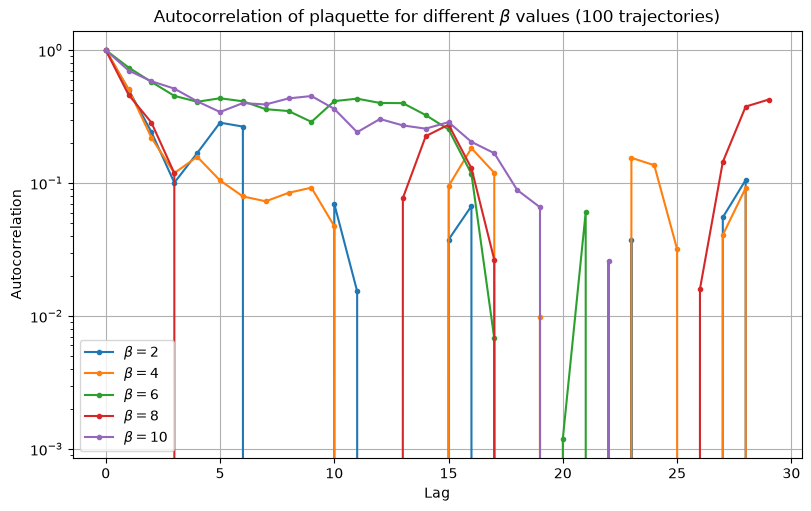

In [131]:
fig, ax = plt.subplots(figsize=(8,5), layout="constrained")

plot_autocorr(ac_plaq_beta2_traj100, "plaquette", ax=ax, label=r"$\beta=2$")
plot_autocorr(ac_plaq_beta4_traj100, "plaquette", ax=ax, label=r"$\beta=4$")
plot_autocorr(ac_plaq_beta6_traj100, "plaquette", ax=ax, label=r"$\beta=6$")
plot_autocorr(ac_plaq_beta8_traj100, "plaquette", ax=ax, label=r"$\beta=8$")
plot_autocorr(ac_plaq_beta10_traj100, "plaquette", ax=ax, label=r"$\beta=10$")

ax.legend()

plt.title(r"Autocorrelation of plaquette for different $\beta$ values (100 trajectories)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.yscale("log")
plt.show()

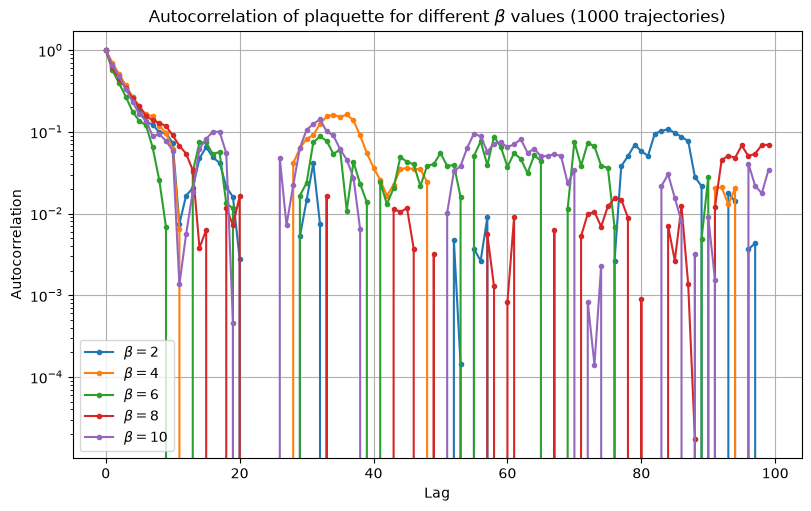

In [132]:
fig, ax = plt.subplots(figsize=(8,5), layout="constrained")

plot_autocorr(ac_plaq_beta2_traj1000, "plaquette", ax=ax, label=r"$\beta=2$")
plot_autocorr(ac_plaq_beta4_traj1000, "plaquette", ax=ax, label=r"$\beta=4$")
plot_autocorr(ac_plaq_beta6_traj1000, "plaquette", ax=ax, label=r"$\beta=6$")
plot_autocorr(ac_plaq_beta8_traj1000, "plaquette", ax=ax, label=r"$\beta=8$")
plot_autocorr(ac_plaq_beta10_traj1000, "plaquette", ax=ax, label=r"$\beta=10$")

ax.legend()

plt.title(r"Autocorrelation of plaquette for different $\beta$ values (1000 trajectories)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.yscale("log")
plt.show()

In [133]:
def integrated_autocorr_time(df, value, W): #integrated autocorrelation time, W = window size

    ac_df = autocorr(df, value, W+1)

    tau_int = 0.5 + np.sum(ac_df["autocorr"][1:])

    return tau_int

In [134]:
def integrated_autocorr_time_scan(df, value, W):

    N = len(df)

    ac_df = autocorr(df, value, W + 1)

    tau_ints = []
    delta_taus = []

    for w in range(1, W + 1):

        tau_int = 0.5 + np.sum(
            ac_df["autocorr"][1:w + 1]
        )

        # Wolff error formula
        argument = w + 0.5 - tau_int

        if argument > 0:
            delta_tau = (
                2 * tau_int
                * np.sqrt(argument / N)
            )
        else:
            delta_tau = np.nan

        tau_ints.append(tau_int)
        delta_taus.append(delta_tau)

    return pd.DataFrame({
        "W": range(1, W + 1),
        "tau_int": tau_ints,
        "delta_tau": delta_taus
    })

In [135]:
int_act_scan_beta2_traj100 =integrated_autocorr_time_scan(df_beta2_traj100, "plaquette", 30)
int_act_scan_beta4_traj100 =integrated_autocorr_time_scan(df_beta4_traj100, "plaquette", 30)
int_act_scan_beta6_traj100 =integrated_autocorr_time_scan(df_beta6_traj100, "plaquette", 30)
int_act_scan_beta8_traj100 =integrated_autocorr_time_scan(df_beta8_traj100, "plaquette", 30)
int_act_scan_beta10_traj100 =integrated_autocorr_time_scan(df_beta10_traj100, "plaquette", 30)

In [136]:
int_act_scan_beta2_traj1000 =integrated_autocorr_time_scan(df_beta2_traj1000, "plaquette", 30)
int_act_scan_beta4_traj1000 =integrated_autocorr_time_scan(df_beta4_traj1000, "plaquette", 30)
int_act_scan_beta6_traj1000 =integrated_autocorr_time_scan(df_beta6_traj1000, "plaquette", 30)
int_act_scan_beta8_traj1000 =integrated_autocorr_time_scan(df_beta8_traj1000, "plaquette", 30)
int_act_scan_beta10_traj1000 =integrated_autocorr_time_scan(df_beta10_traj1000, "plaquette", 30)

In [137]:
print(int_act_scan_beta2_traj100.head(10))

    W   tau_int  delta_tau
0   1  1.003215   0.149069
1   2  1.244712   0.294001
2   3  1.345261   0.416306
3   4  1.513079   0.551293
4   5  1.797625   0.729202
5   6  2.063529   0.916301
6   7  2.040352   1.005070
7   8  1.888672   1.023787
8   9  1.761070   1.032823
9  10  1.830769   1.136403


In [138]:
def plot_int_autocorr(
    df,
    ax=None,
    title=None,
    label=None,
    color=None
):

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(8, 5),
            layout="constrained"
        )

    # -------------------------
    # tau_int(W)
    # -------------------------

    ax.plot(
        df["W"],
        df["tau_int"],
        ".-",
        color=color,
        label=label,
        linewidth=1.5,
        markersize=4
    )

    # -------------------------
    # Fehlerband
    # -------------------------

    valid = (
        df["delta_tau"].notna()
        & (df["delta_tau"] >= 0)
    )

    ax.fill_between(
        df.loc[valid, "W"],
        df.loc[valid, "tau_int"]
        - df.loc[valid, "delta_tau"],
        df.loc[valid, "tau_int"]
        + df.loc[valid, "delta_tau"],
        color=color,
        alpha=0.2
    )

    # -------------------------
    # labels
    # -------------------------

    ax.set_xlabel(r"$W$")
    ax.set_ylabel(r"$\tau_{\mathrm{int}}(W)$")

    ax.grid(True, alpha=0.3)

    if title:
        ax.set_title(title)

    return ax

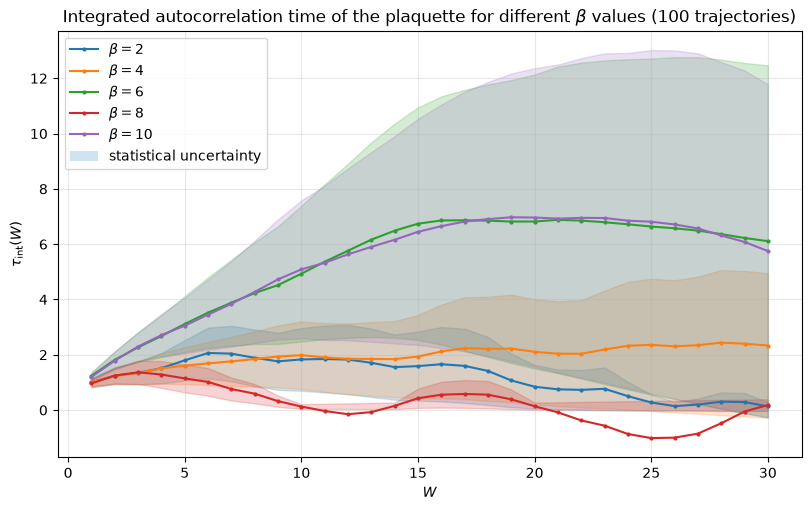

In [139]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(
    figsize=(8, 5),
    layout="constrained"
)

plot_int_autocorr(
    int_act_scan_beta2_traj100,
    ax=ax,
    label=r"$\beta=2$",
    color="tab:blue"
)

plot_int_autocorr(
    int_act_scan_beta4_traj100,
    ax=ax,
    label=r"$\beta=4$",
    color="tab:orange"
)

plot_int_autocorr(
    int_act_scan_beta6_traj100,
    ax=ax,
    label=r"$\beta=6$",
    color="tab:green"
)

plot_int_autocorr(
    int_act_scan_beta8_traj100,
    ax=ax,
    label=r"$\beta=8$",
    color="tab:red"
)

plot_int_autocorr(
    int_act_scan_beta10_traj100,
    ax=ax,
    label=r"$\beta=10$",
    color="tab:purple"
)

# Dummy handle für das Fehlerband
uncertainty_patch = Patch(
    alpha=0.2,
    label=r"statistical uncertainty"
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles + [uncertainty_patch],
    labels + [r"statistical uncertainty"]
)

ax.set_title(
    r"Integrated autocorrelation time of the plaquette "
    r"for different $\beta$ values (100 trajectories)"
)

plt.show()

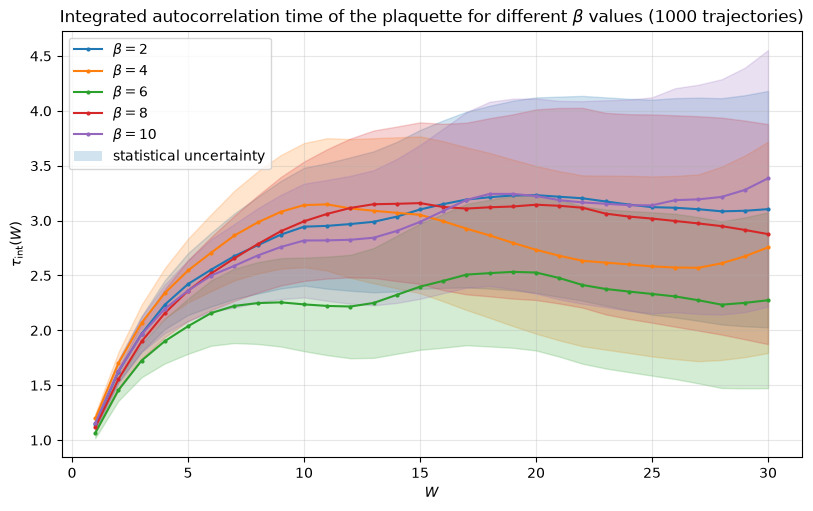

In [140]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(
    figsize=(8, 5),
    layout="constrained"
)

plot_int_autocorr(
    int_act_scan_beta2_traj1000,
    ax=ax,
    label=r"$\beta=2$",
    color="tab:blue"
)

plot_int_autocorr(
    int_act_scan_beta4_traj1000,
    ax=ax,
    label=r"$\beta=4$",
    color="tab:orange"
)

plot_int_autocorr(
    int_act_scan_beta6_traj1000,
    ax=ax,
    label=r"$\beta=6$",
    color="tab:green"
)

plot_int_autocorr(
    int_act_scan_beta8_traj1000,
    ax=ax,
    label=r"$\beta=8$",
    color="tab:red"
)

plot_int_autocorr(
    int_act_scan_beta10_traj1000,
    ax=ax,
    label=r"$\beta=10$",
    color="tab:purple"
)

# Dummy handle für das Fehlerband
uncertainty_patch = Patch(
    alpha=0.2,
    label=r"statistical uncertainty"
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles + [uncertainty_patch],
    labels + [r"statistical uncertainty"]
)

ax.set_title(
    r"Integrated autocorrelation time of the plaquette "
    r"for different $\beta$ values (1000 trajectories)"
)

plt.show()

In [141]:
def tau_exp_from_tau_int(tau_int, S=1):

    tau_exp = np.zeros_like(tau_int)

    for i, tau in enumerate(tau_int):

        if tau <= 0.5:
            tau_exp[i] = 1e-10

        else:
            tau_exp[i] = S / np.log(
                (2*tau + 1) /
                (2*tau - 1)
            )

    return tau_exp

In [142]:
def window(tau_exp, N):

    g = []

    for W in range(1, len(tau_exp)):

        value = (
            np.exp(-W/tau_exp[W])
            -
            tau_exp[W]/(np.sqrt(W)*N)
        )

        g.append(value)

    return np.array(g)

In [143]:
def find_optimal_W(df, value, Wmax, S=1):

    N = len(df)

    tau_int_df = integrated_autocorr_time_scan(df, value, Wmax)

    tau_int = tau_int_df["tau_int"].values
    delta_tau = tau_int_df["delta_tau"].values

    tau_exp = tau_exp_from_tau_int(tau_int, S)

    g = window(tau_exp, N)

    # erstes W mit g(W)<0
    for W in range(len(g)):

        if g[W] < 0:
            W_opt = W+1
            break

    return {
        "W": W_opt,
        "tau_int": tau_int[W_opt],
        "delta_tau": delta_tau[W_opt],
        "tau_exp": tau_exp[W_opt],
    }

In [144]:
print(find_optimal_W(df_beta2_traj100, "plaquette", 40))
print(find_optimal_W(df_beta4_traj100, "plaquette", 40))
print(find_optimal_W(df_beta6_traj100, "plaquette", 40))
print(find_optimal_W(df_beta8_traj100, "plaquette", 40))
print(find_optimal_W(df_beta10_traj100, "plaquette", 40))

{'W': 9, 'tau_int': np.float64(1.830768743082902), 'delta_tau': np.float64(1.1364033991468176), 'tau_exp': np.float64(1.7843079698692401)}
{'W': 10, 'tau_int': np.float64(1.9023683359573118), 'delta_tau': np.float64(1.2424685056937796), 'tau_exp': np.float64(1.8577257690678468)}
{'W': 28, 'tau_int': np.float64(6.223263673483502), 'delta_tau': np.float64(6.329770827543882), 'tau_exp': np.float64(6.209849929239771)}
{'W': 5, 'tau_int': np.float64(1.0169397762281744), 'delta_tau': np.float64(0.5020136008505619), 'tau_exp': np.float64(0.9289157456988404)}
{'W': 28, 'tau_int': np.float64(6.079449490521582), 'delta_tau': np.float64(6.202568155255552), 'tau_exp': np.float64(6.065717296145197)}


In [145]:
print(find_optimal_W(df_beta2_traj1000, "plaquette", 200))
print(find_optimal_W(df_beta4_traj1000, "plaquette", 200))
print(find_optimal_W(df_beta6_traj1000, "plaquette", 200))
print(find_optimal_W(df_beta8_traj1000, "plaquette", 200))
print(find_optimal_W(df_beta10_traj1000, "plaquette", 200))

{'W': 23, 'tau_int': np.float64(3.1463302136642373), 'delta_tau': np.float64(0.9639396875405536), 'tau_exp': np.float64(3.1196635649589703)}
{'W': 20, 'tau_int': np.float64(2.679939911182599), 'delta_tau': np.float64(0.7708055958756277), 'tau_exp': np.float64(2.6485506647629724)}
{'W': 19, 'tau_int': np.float64(2.527024819362575), 'delta_tau': np.float64(0.7102787049809325), 'tau_exp': np.float64(2.493696449352725)}
{'W': 23, 'tau_int': np.float64(3.037077929877401), 'delta_tau': np.float64(0.9328453686007198), 'tau_exp': np.float64(3.0094380920455372)}
{'W': 23, 'tau_int': np.float64(3.140366956459932), 'delta_tau': np.float64(0.9622470584031778), 'tau_exp': np.float64(3.113648972537237)}


In [146]:
def autocorr_error(df, value, groupby, Wmax, S=1):

    results = []

    for group, group_df in df.groupby(groupby):

        N = len(group_df)

        # Wolff analysis
        result = find_optimal_W(group_df, value, Wmax, S)

        tau_int = result["tau_int"]
        delta_tau = result["delta_tau"]
        W_opt = result["W"]

        gamma0 = np.var(group_df[value].values, ddof=0)

        sigma = np.sqrt(
            2 * tau_int * gamma0 / N
        )

        results.append({
            groupby: group,
            "tau_int": tau_int, 
            "delta_tau": delta_tau,
            "W_opt": W_opt,
            "gamma0": gamma0,
            "sem_autocorr": sigma
        })

    return pd.DataFrame(results)

In [147]:
plaq_error_traj100 = autocorr_error(df_traj100, "plaquette", "beta", 40)
plaq_error_traj1000 = autocorr_error(df_traj1000, "plaquette", "beta", 40)

In [148]:
df_mdstep5_traj100 =df_phys_mdsteps_traj100[df_phys_mdsteps_traj100.mdsteps == 5] 
df_mdstep8_traj100 =df_phys_mdsteps_traj100[df_phys_mdsteps_traj100.mdsteps == 8]
df_mdstep10_traj100 = df_phys_mdsteps_traj100[df_phys_mdsteps_traj100.mdsteps == 10]
df_mdstep20_traj100 = df_phys_mdsteps_traj100[df_phys_mdsteps_traj100.mdsteps == 20]

df_mdstep5_traj1000 =df_phys_mdsteps_traj1000[df_phys_mdsteps_traj1000.mdsteps == 5] 
df_mdstep8_traj1000 =df_phys_mdsteps_traj1000[df_phys_mdsteps_traj1000.mdsteps == 8]
df_mdstep10_traj1000 = df_phys_mdsteps_traj1000[df_phys_mdsteps_traj1000.mdsteps == 10]
df_mdstep20_traj1000 = df_phys_mdsteps_traj1000[df_phys_mdsteps_traj1000.mdsteps == 20]

df_trajL05_traj100 = df_phys_trajL_traj100[df_phys_trajL_traj100.trajL == 0.5]
df_trajL1_traj100 = df_phys_trajL_traj100[df_phys_trajL_traj100.trajL == 1.0]
df_trajL125_traj100 = df_phys_trajL_traj100[df_phys_trajL_traj100.trajL == 1.25]
df_trajL2_traj100 = df_phys_trajL_traj100[df_phys_trajL_traj100.trajL == 2.0]

df_trajL05_traj1000 = df_phys_trajL_traj1000[df_phys_trajL_traj1000.trajL == 0.5]
df_trajL1_traj1000 = df_phys_trajL_traj1000[df_phys_trajL_traj1000.trajL == 1.0]
df_trajL125_traj1000 = df_phys_trajL_traj1000[df_phys_trajL_traj1000.trajL == 1.25]
df_trajL2_traj1000 = df_phys_trajL_traj1000[df_phys_trajL_traj1000.trajL == 2.0]

In [149]:
def measurement_stats(df, value, groupby):

    stats = (
        df
        .groupby(groupby)[value]
        .agg(
            N="count",
            mean="mean",
            std="std"
        )
        .sort_index()
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats.reset_index()

In [150]:
df_plaq_traj100= measurement_stats(df_phys_traj100, "plaquette", "beta")
df_plaq_traj1000= measurement_stats(df_phys_traj1000, "plaquette", "beta")

df_plaq_mdsteps_traj100= measurement_stats(df_phys_mdsteps_traj100, "plaquette", "mdsteps")
df_plaq_mdsteps_traj1000= measurement_stats(df_phys_mdsteps_traj1000, "plaquette", "mdsteps")

df_plaq_trajL_traj100= measurement_stats(df_phys_trajL_traj100, "plaquette", "trajL")
df_plaq_trajL_traj1000= measurement_stats(df_phys_trajL_traj1000, "plaquette", "trajL")

In [151]:
stats_traj100 = measurement_stats(df_phys_traj100, "plaquette", "beta")
corr_traj100 = autocorr_error(df_phys_traj100, "plaquette", "beta", Wmax=90)

df_plaq_traj100 = stats_traj100.merge(corr_traj100, on="beta")

stats_traj1000 = measurement_stats(df_phys_traj1000, "plaquette", "beta")
corr_traj1000 = autocorr_error(df_phys_traj1000, "plaquette", "beta", Wmax=900)

df_plaq_traj1000 = stats_traj1000.merge(corr_traj1000, on="beta")

stats_mdsteps_traj100 = measurement_stats(df_phys_mdsteps_traj100, "plaquette", "mdsteps")
corr_mdsteps_traj100 = autocorr_error(df_phys_mdsteps_traj100, "plaquette", "mdsteps", Wmax=90)

df_plaq_mdsteps_traj100 = stats_mdsteps_traj100.merge(corr_mdsteps_traj100, on="mdsteps")


stats_mdsteps_traj1000 = measurement_stats(df_phys_mdsteps_traj1000, "plaquette", "mdsteps")
corr_mdsteps_traj1000 = autocorr_error(df_phys_mdsteps_traj1000, "plaquette", "mdsteps", Wmax=900)

df_plaq_mdsteps_traj1000 = stats_mdsteps_traj1000.merge(corr_mdsteps_traj1000, on="mdsteps")


stats_trajL_traj100 = measurement_stats(df_phys_trajL_traj100, "plaquette", "trajL")
corr_trajL_traj100 = autocorr_error(df_phys_trajL_traj100, "plaquette", "trajL", Wmax=90)

df_plaq_trajL_traj100 = stats_trajL_traj100.merge(corr_trajL_traj100, on="trajL")


stats_trajL_traj1000 = measurement_stats(df_phys_trajL_traj1000, "plaquette", "trajL")
corr_trajL_traj1000 = autocorr_error(df_phys_trajL_traj1000, "plaquette", "trajL", Wmax=900)

df_plaq_trajL_traj1000 = stats_trajL_traj1000.merge(corr_trajL_traj1000, on="trajL")


/var/folders/gn/0cpq6tpx3mb7dr15cprkp6s00000gn/T/ipykernel_7157/1981697336.py:13: RuntimeWarning: invalid value encountered in scalar divide
  gamma = np.sum((x1 - mean)*(x2 - mean))/(N-lag)


In [152]:
latex_table_plaq_traj100 = df_plaq_traj100.to_latex(index=False) 
latex_table_plaq_traj1000 = df_plaq_traj1000.to_latex(index=False)

latex_table_plaq_mdsteps_traj100 = df_plaq_mdsteps_traj100.to_latex(index=False) 
latex_table_plaq_mdsteps_traj1000 = df_plaq_mdsteps_traj1000.to_latex(index=False)

latex_table_plaq_trajL_traj100 = df_plaq_trajL_traj100.to_latex(index=False) 
latex_table_plaq_trajL_traj1000 = df_plaq_trajL_traj1000.to_latex(index=False)


print(latex_table_plaq_traj100)
print(latex_table_plaq_traj1000)

print(latex_table_plaq_mdsteps_traj100)
print(latex_table_plaq_mdsteps_traj1000)

print(latex_table_plaq_trajL_traj100)
print(latex_table_plaq_trajL_traj1000)

\begin{tabular}{rrrrrrrrrr}
\toprule
beta & N & mean & std & sem & tau_int & delta_tau & W_opt & gamma0 & sem_autocorr \\
\midrule
2.000000 & 90 & 0.501305 & 0.003287 & 0.000346 & 1.830769 & 1.136403 & 9 & 0.000011 & 0.000659 \\
4.000000 & 90 & 0.799032 & 0.001182 & 0.000125 & 1.902368 & 1.242469 & 10 & 0.000001 & 0.000242 \\
6.000000 & 90 & 0.869522 & 0.001250 & 0.000132 & 6.223264 & 6.329771 & 28 & 0.000002 & 0.000462 \\
8.000000 & 90 & 0.903327 & 0.000695 & 0.000073 & 1.016940 & 0.502014 & 5 & 0.000000 & 0.000104 \\
10.000000 & 90 & 0.923347 & 0.000681 & 0.000072 & 6.079449 & 6.202568 & 28 & 0.000000 & 0.000249 \\
\bottomrule
\end{tabular}

\begin{tabular}{rrrrrrrrrr}
\toprule
beta & N & mean & std & sem & tau_int & delta_tau & W_opt & gamma0 & sem_autocorr \\
\midrule
2.000000 & 910 & 0.501585 & 0.003472 & 0.000115 & 3.146330 & 0.963940 & 23 & 0.000012 & 0.000289 \\
4.000000 & 910 & 0.799586 & 0.001505 & 0.000050 & 2.679940 & 0.770806 & 20 & 0.000002 & 0.000115 \\
6.000000 & 910 & 

In [248]:
def plot_plaquette_avr_beta(df, trajectories=None):

    plt.figure(figsize=(8,5))

    dx = 0.01

    # Naiver Fehler
    plt.errorbar(
        df["beta"] - dx,
        df["mean"],
        yerr=df["sem"],
        fmt="o",
        capsize=3,
        label="Naiver Fehler"
    )

    # Wolff-Fehler
    plt.errorbar(
        df["beta"] + dx,
        df["mean"],
        yerr=df["sem_autocorr"],
        fmt="s",
        capsize=3,
        label="Autokorrelations-korrigiert"
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel(r"$\langle P\rangle$")

    if trajectories is not None:
        plt.title(
            rf"$\langle P\rangle$ vs $\beta$: {trajectories} trajectories"
        )
    else:
        plt.title(r"$\langle P\rangle$ vs $\beta$")

    plt.legend()
    plt.grid()
    plt.show()

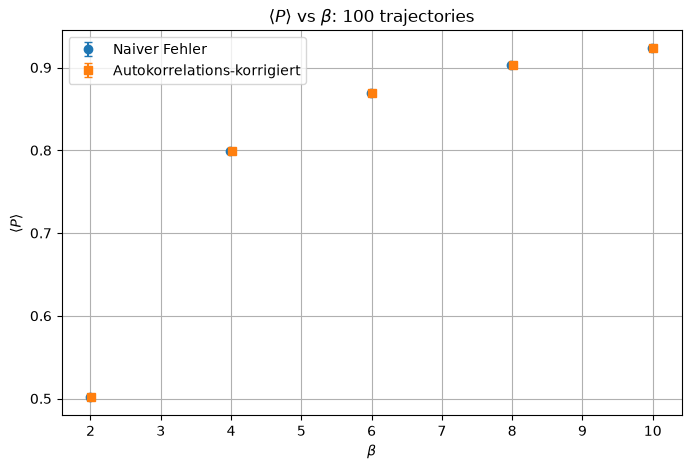

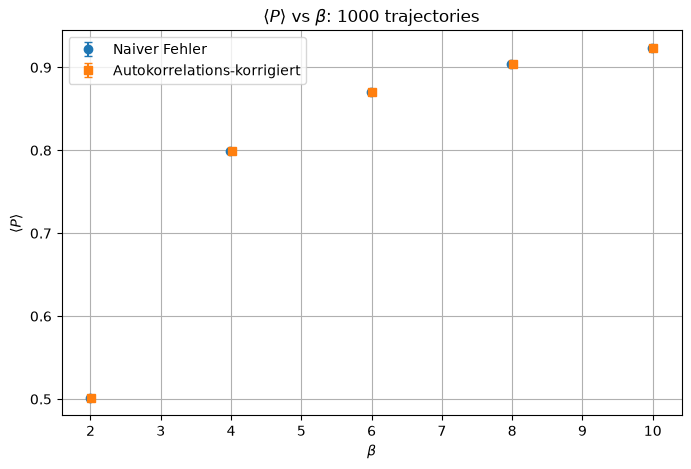

In [249]:
plot_plaquette_avr_beta(df_plaq_traj100, trajectories=100)
plot_plaquette_avr_beta(df_plaq_traj1000, trajectories=1000)

In [250]:
import re

def parse_acceptance(logfile):

    data = []

    with open(logfile) as f:
        trajectory = 0

        for line in f:

            if "Metropolis_test -- ACCEPTED" in line:
                trajectory += 1
                data.append({
                    "trajectory": trajectory,
                    "accepted": 1
                })

            elif "Metropolis_test -- REJECTED" in line:
                trajectory += 1
                data.append({
                    "trajectory": trajectory,
                    "accepted": 0
                })

    return data

In [251]:
measurements = []

for log in logs:

    params = parse_log_name(log)

    acc = parse_acceptance(log)

    for a in acc:
        a.update(params)
        measurements.append(a)

df_acc = pd.DataFrame(measurements)

In [252]:
df_acc_beta_scan = df_acc[
    (df_acc.mdsteps == 10) &
    (df_acc.trajL == 1.0) &
    (df_acc.beta != 5.6)
]

In [253]:
df_acc_100 = df_acc_beta_scan[
    (df_acc_beta_scan.trajectories == 100) &
    (df_acc_beta_scan.trajectory > 10) # kein Metropolistest während des Thermalisierens. entferne 10 weniger Werte als beim Plaquette
]

df_acc_1000 = df_acc_beta_scan[
    (df_acc_beta_scan.trajectories == 1000) &
    (df_acc_beta_scan.trajectory > 90)
]

In [254]:
def acc_stats(df):
    stats =(
    df    
    .groupby("beta")
    .agg(
        N=("accepted", "count"),
        accepted=("accepted", "sum"),
        acceptance=("accepted", "mean")
        )       
    )
    return stats.reset_index()

In [255]:
df_acc_100.groupby(["beta", "mdsteps", "trajL"]).size()

beta  mdsteps  trajL
2.0   10       1.0      90
4.0   10       1.0      90
6.0   10       1.0      90
8.0   10       1.0      90
10.0  10       1.0      90
dtype: int64

In [256]:
acc_100 = acc_stats(df_acc_100)
acc_1000 = acc_stats(df_acc_1000) 

In [257]:
print(acc_100.to_latex(index=False))
print(acc_1000.to_latex(index=False))

ImportError: `Import Jinja2` failed. DataFrame.style requires jinja2. Use pip or conda to install the Jinja2 package.

In [258]:
def plot_acceptance(df_stats, trajectories=None):

    plt.figure(figsize=(7,5))

    plt.plot(
        df_stats.index,
        df_stats["acceptance"],
        "o"
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel("Acceptance rate")

    if trajectories:
        plt.title(
            f"Acceptance rate ({trajectories} trajectories)"
        )

    #plt.ylim(0,1.05)
    plt.grid()

    plt.show()

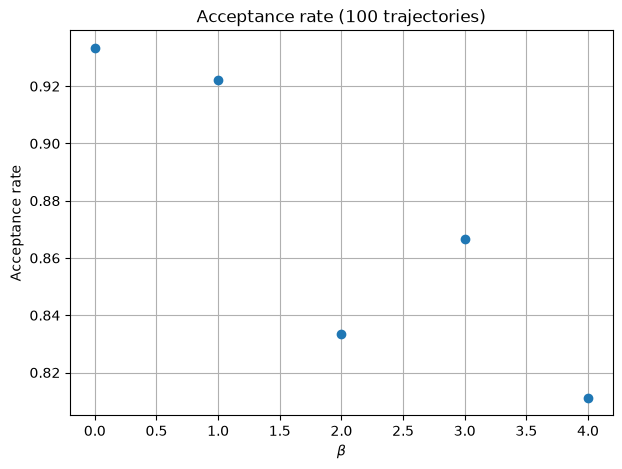

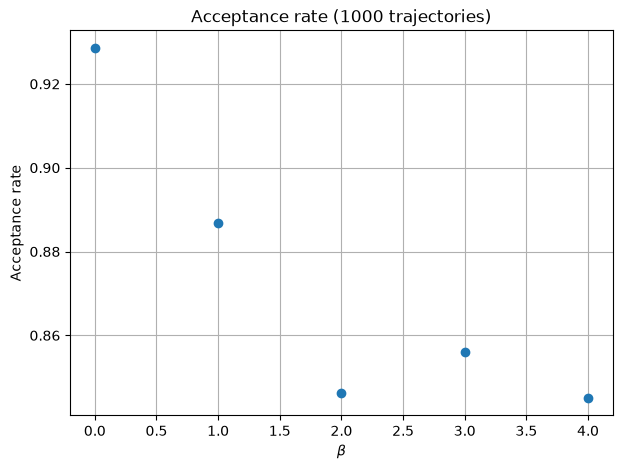

In [259]:
plot_acceptance(acc_100, trajectories=100)
plot_acceptance(acc_1000, trajectories=1000)

In [260]:
def parse_dH(logfile):

    data = []

    current_traj = None

    with open(logfile) as f:
        for line in f:

            m_traj = re.search(
                r"Plaquette:\s+\[\s*(\d+)\s*\]",
                line
            )

            if m_traj:
                current_traj = int(m_traj.group(1))


            m_dh = re.search(
                r"Total H after trajectory\s*=\s*([\d\.Ee+-]+)\s+dH\s*=\s*([\d\.Ee+-]+)",
                line
            )

            if m_dh and current_traj is not None:

                data.append({
                    "trajectory": current_traj,
                    "H_after": float(m_dh.group(1)),
                    "dH": float(m_dh.group(2))
                })

    return pd.DataFrame(data)

In [261]:
dh_measurements = []

for log in logs:

    dh = parse_dH(log)

    params = parse_log_name(log)

    for key,value in params.items():
        dh[key] = value

    dh["file"] = log.name

    dh_measurements.append(dh)


df_dh = pd.concat(dh_measurements)

df_dh = df_dh.drop_duplicates(
    subset=["file","trajectory"]
)


In [316]:
df_dh["exp_minus_dH"] = np.exp(-df_dh["dH"])

df_beta_scan_dh = df_dh[(df_dh.mdsteps == 10) & (df_dh.trajL == 1.0) & (df_dh.beta != 5.6)]
df_mdsteps_scan_dh = df_dh[(df_dh.beta == 2) & (df_dh.trajL == 1.0) & (df_dh.mdsteps != 40)]
df_trajL_scan_dh = df_dh[(df_dh.beta == 2) & (df_dh.mdsteps == 10)]

df_dh_traj100 = df_beta_scan_dh[(df_beta_scan_dh.trajectories==100)&(df_beta_scan_dh.trajectory >19)]
df_dh_traj1000 = df_beta_scan_dh[(df_beta_scan_dh.trajectories==1000)&(df_beta_scan_dh.trajectory >99)]

df_dh_mdsteps_traj100 = df_mdsteps_scan_dh[(df_mdsteps_scan_dh.trajectories==100)&(df_mdsteps_scan_dh.trajectory >19)]
df_dh_mdsteps_traj1000 = df_mdsteps_scan_dh[(df_mdsteps_scan_dh.trajectories==1000)&(df_mdsteps_scan_dh.trajectory >99)]

df_dh_trajL_traj100 = df_trajL_scan_dh[(df_trajL_scan_dh.trajectories==100)&(df_trajL_scan_dh.trajectory >19)]
df_dh_trajL_traj1000 = df_trajL_scan_dh[(df_trajL_scan_dh.trajectories==1000)&(df_trajL_scan_dh.trajectory >99)]


In [317]:
df_mdsteps5_dh = df_dh[(df_dh.mdsteps == 5)] #Achtung: für reversibility angepasst
df_mdsteps10_dh = df_dh[(df_dh.mdsteps == 10)]
df_mdsteps15_dh = df_dh[(df_dh.mdsteps == 15)]
df_mdsteps20_dh = df_dh[(df_dh.mdsteps == 20)]

In [318]:
def dH_stats(df):
    stats =(
    df    
    .groupby("beta")
    .dH
    .agg(
        mean="mean",
        std="std",
        N="count"
        )       
    )

    stats["sem"] = (
    stats["std"] /
    np.sqrt(stats["N"])
    )

    return stats

In [319]:
df_mdsteps_traj100.head()

,trajectory,plaquette,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
1010,1,0.291019,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
1011,2,0.387264,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
1012,3,0.437674,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
1013,4,0.463869,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
1014,5,0.477317,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log


In [320]:
dh_stats_traj100 = measurement_stats(df_dh_traj100, "dH" , "beta")
dh_stats_traj1000 = measurement_stats(df_dh_traj1000, "dH" , "beta")

dh_stats_mdsteps_traj100 = measurement_stats(df_dh_mdsteps_traj100, "dH", "mdsteps")
dh_stats_mdsteps_traj1000 = measurement_stats(df_dh_mdsteps_traj1000, "dH", "mdsteps")

dh_stats_trajL_traj100 = measurement_stats(df_dh_trajL_traj100, "dH", "trajL")
dh_stats_trajL_traj1000 = measurement_stats(df_dh_trajL_traj1000, "dH", "trajL")

In [321]:
df_dh_traj100

,trajectory,H_after,dH,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file,exp_minus_dH
19,20,44805.944017,-0.092202,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,1.096587
20,21,44575.959427,0.238086,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,0.788135
21,22,44728.251590,-0.039821,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,1.040625
22,23,44536.088501,-0.248131,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,1.281628
23,24,44140.430006,0.303995,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,0.737865
...,...,...,...,...,...,...,...,...,...,...,...
104,105,43499.054243,0.054732,8x8x8x8,10.0,10,1.0,100,5,L8x8x8x8_beta10_md10_trajL1.0_traj100_ckpt5.log,0.946739
105,106,43882.445291,0.283743,8x8x8x8,10.0,10,1.0,100,5,L8x8x8x8_beta10_md10_trajL1.0_traj100_ckpt5.log,0.752960
106,107,43901.856333,-0.736199,8x8x8x8,10.0,10,1.0,100,5,L8x8x8x8_beta10_md10_trajL1.0_traj100_ckpt5.log,2.087984
107,108,43596.361704,0.506214,8x8x8x8,10.0,10,1.0,100,5,L8x8x8x8_beta10_md10_trajL1.0_traj100_ckpt5.log,0.602773


In [322]:
dh_corr_traj100 = autocorr_error(df_dh_traj100, "dH", "beta", Wmax=90)

df_dh_traj100 = dh_stats_traj100.merge(dh_corr_traj100, on="beta")

dh_corr_traj1000 = autocorr_error(df_dh_traj1000, "dH", "beta", Wmax=900)

df_dh_traj1000 = dh_stats_traj1000.merge(dh_corr_traj1000, on="beta")

/var/folders/gn/0cpq6tpx3mb7dr15cprkp6s00000gn/T/ipykernel_2521/1981697336.py:13: RuntimeWarning: invalid value encountered in scalar divide
  gamma = np.sum((x1 - mean)*(x2 - mean))/(N-lag)


In [267]:
dh_stats_mdsteps5 = measurement_stats(df_mdsteps5_dh, "dH", "mdsteps")  # Achtung: für reversibility angepasst
dh_stats_mdsteps10 = measurement_stats(df_mdsteps10_dh, "dH", "mdsteps")
dh_stats_mdsteps15 = measurement_stats(df_mdsteps15_dh, "dH", "mdsteps")
dh_stats_mdsteps20 = measurement_stats(df_mdsteps20_dh, "dH", "mdsteps")

In [268]:
dh_mdsteps_revers = pd.concat([dh_stats_mdsteps5, dh_stats_mdsteps10, dh_stats_mdsteps15, dh_stats_mdsteps20], ignore_index=True)

In [ ]:
#dh_mdsteps_revers.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/dH_measurements_mdsteps_revers.csv", index=False)

In [269]:
#Plotfunktion dH vs trajectories für alle beta
def plot_dH_history(df_plot, title=None):
    
    plt.figure(figsize=(8,5))

    for beta in sorted(df_plot.beta.unique()):
        subset = (
            df_plot[df_plot.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.dH,
            ".",
            alpha=0.5,
            label=fr"$\beta={beta}$"
        )

    plt.xlabel("trajectory")
    plt.ylabel("dH")
    plt.legend()
    plt.grid()
    plt.axhline(0)

    if title:
        plt.title(title)

    plt.show()

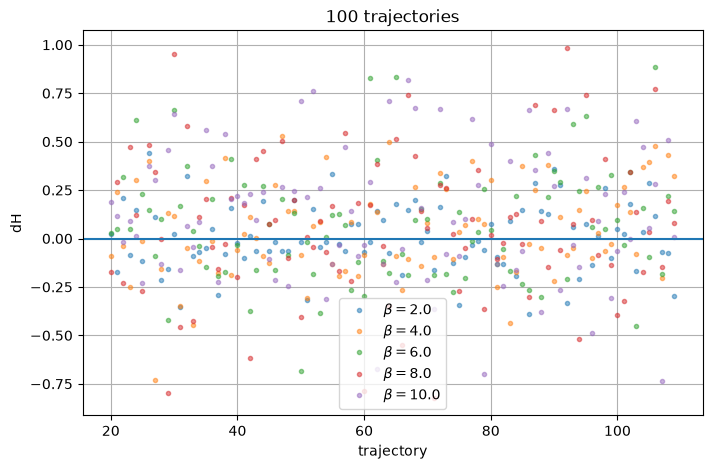

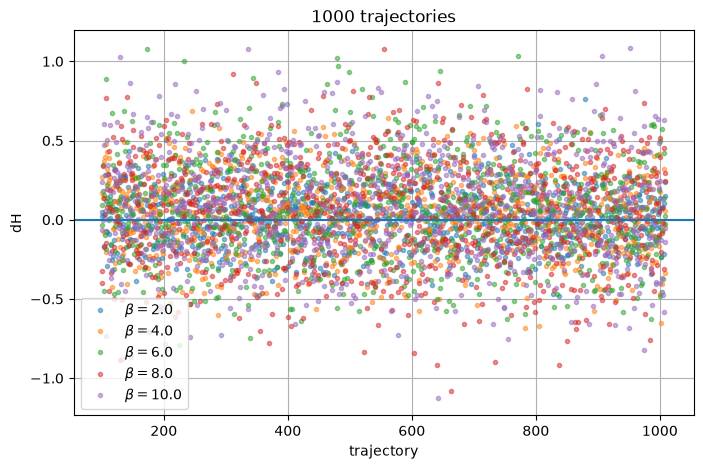

In [270]:
plot_dH_history(df_dh_traj100, title="100 trajectories")
plot_dH_history(df_dh_traj1000, title="1000 trajectories")

In [271]:
def plot_dH_histogram(df, beta=None, bins=40):

    plt.figure(figsize=(8,5))

    # Anzahl der Trajektorien aus DataFrame holen
    if "trajectories" in df.columns:
        traj_values = df.trajectories.unique()
        if len(traj_values) == 1:
            trajectories = traj_values[0]
        else:
            trajectories = None
    else:
        trajectories = None


    if beta is not None:

        df_plot = df[df.beta == beta]

        plt.hist(
            df_plot.dH,
            bins=bins,
            density=True,
            rwidth=0.9,
            alpha=0.7
        )

        title = (
            fr"$\Delta H$ distribution, "
            fr"$\beta={beta}$"
        )

    else:

        for b in sorted(df.beta.unique()):

            plt.hist(
                df[df.beta == b].dH,
                bins=bins,
                density=True,
                alpha=0.5,
                label=fr"$\beta={b}$"
            )

        plt.legend()

        title = r"$\Delta H$ distribution"


    if trajectories is not None:
        title += f" ({trajectories} trajectories)"


    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(r"$\Delta H$")
    plt.ylabel("Probability density")

    plt.title(title)

    plt.grid()

    plt.show()

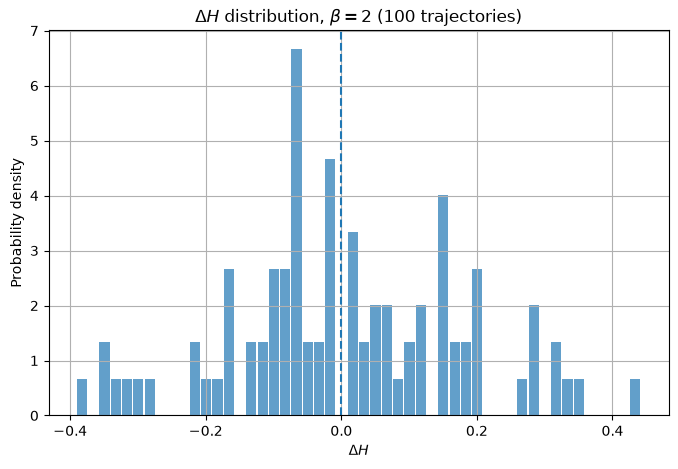

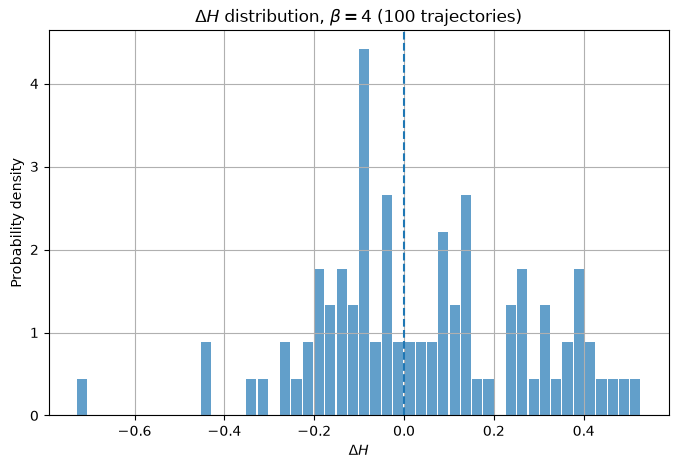

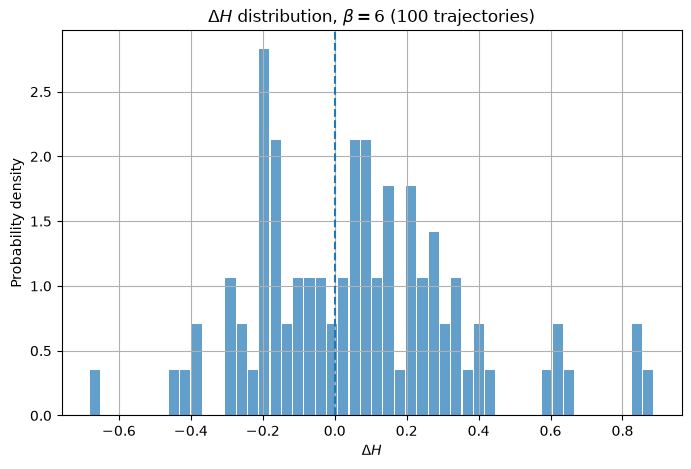

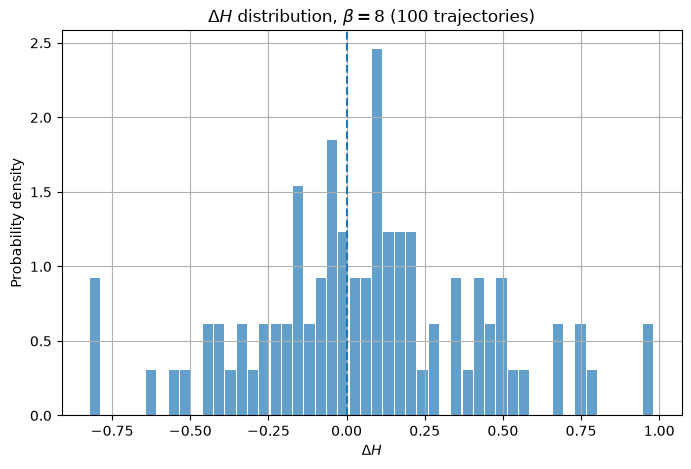

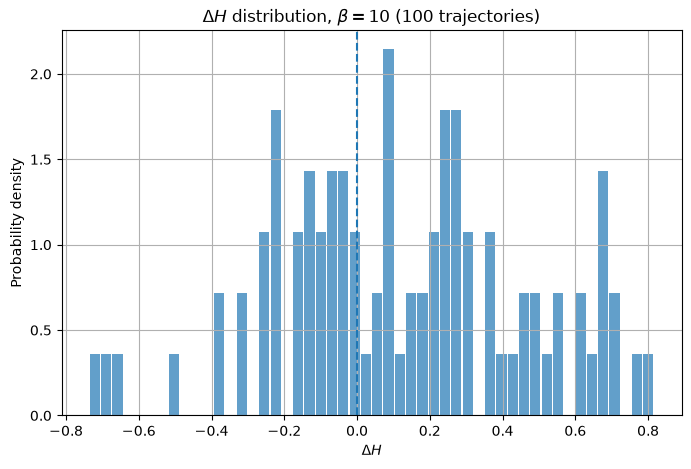

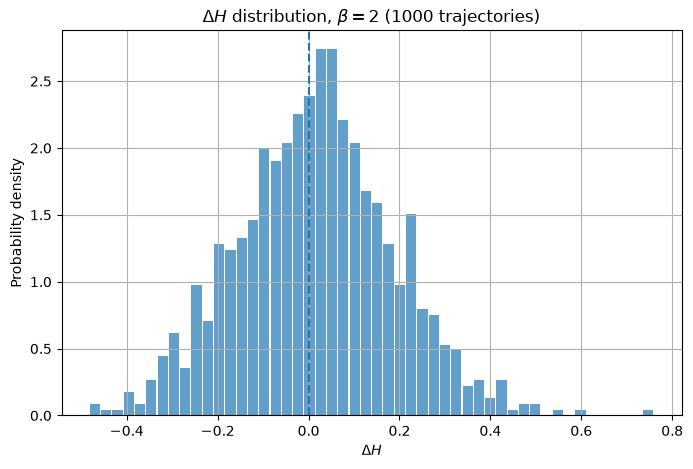

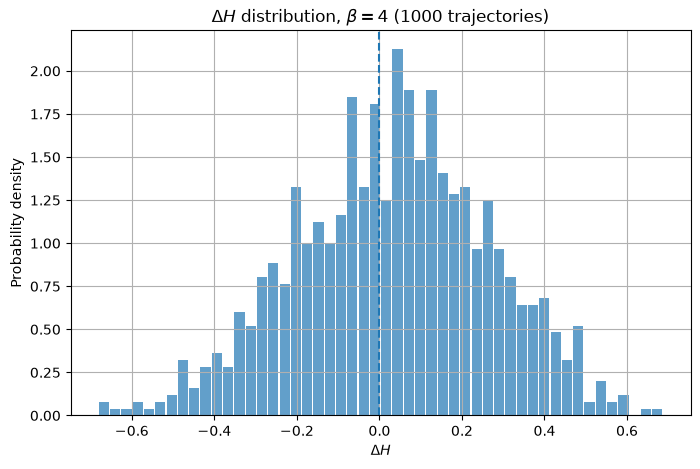

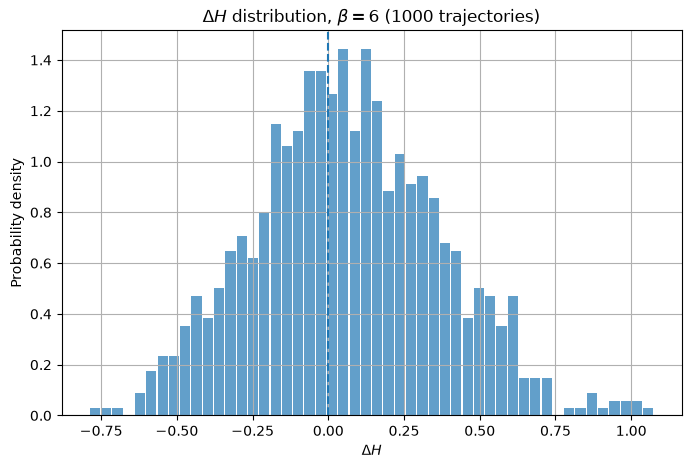

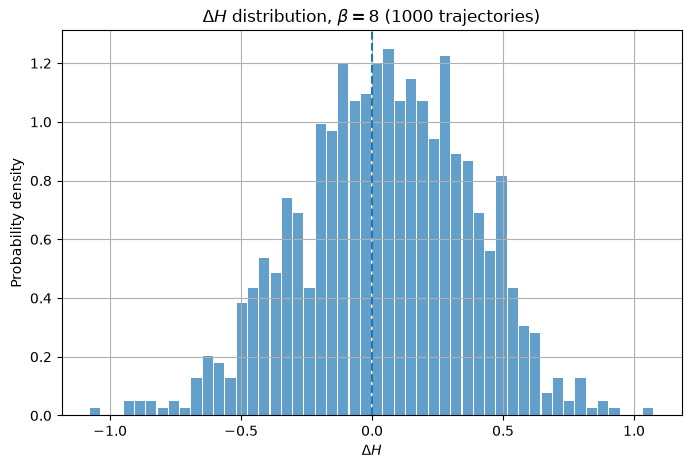

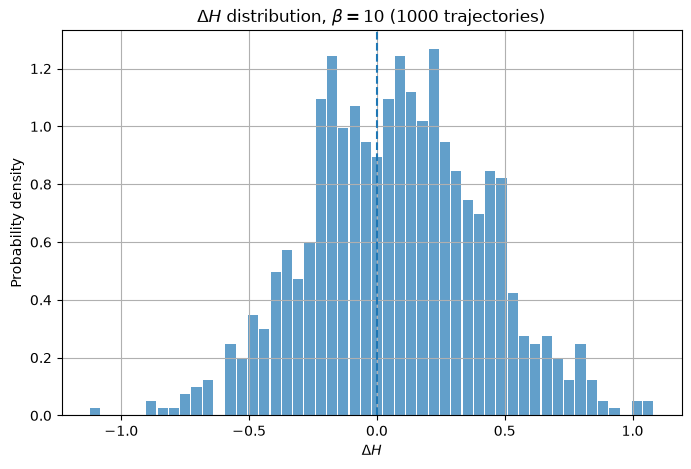

In [272]:
plot_dH_histogram(df_dh_traj100, beta=2, bins=50)
plot_dH_histogram(df_dh_traj100,beta=4, bins=50)
plot_dH_histogram(df_dh_traj100,beta=6, bins=50)
plot_dH_histogram(df_dh_traj100,beta=8, bins=50)
plot_dH_histogram(df_dh_traj100,beta=10, bins=50)

plot_dH_histogram(df_dh_traj1000, beta=2, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=4, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=6, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=8, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=10, bins=50)

In [326]:
analysis_100 = df_dh_traj100.join(acc_100["acceptance"])
analysis_1000 = df_dh_traj1000.join(acc_1000["acceptance"])

#print(analysis_100.to_latex(index=False))
#print(analysis_1000.to_latex(index=False))

In [327]:
analysis_100

,beta,N,mean,std,sem,tau_int,W_opt,gamma0,sem_autocorr,acceptance
0,2.0,90,0.004896,0.173860,0.018326,0.278924,1,0.029891,0.013612,0.933333
1,4.0,90,0.041472,0.239281,0.025222,0.438907,1,0.056619,0.023500,0.922222
2,6.0,90,0.066445,0.292599,0.030843,0.440225,1,0.084663,0.028779,0.833333
3,8.0,90,0.062335,0.370234,0.039026,0.145527,1,0.135550,0.020937,0.866667
4,10.0,90,0.122251,0.342594,0.036113,0.116057,1,0.116067,0.017301,0.811111


In [328]:
df_dh_traj100 

,beta,N,mean,std,sem,tau_int,W_opt,gamma0,sem_autocorr
0,2.0,90,0.004896,0.173860,0.018326,0.278924,1,0.029891,0.013612
1,4.0,90,0.041472,0.239281,0.025222,0.438907,1,0.056619,0.023500
2,6.0,90,0.066445,0.292599,0.030843,0.440225,1,0.084663,0.028779
3,8.0,90,0.062335,0.370234,0.039026,0.145527,1,0.135550,0.020937
4,10.0,90,0.122251,0.342594,0.036113,0.116057,1,0.116067,0.017301


In [329]:
def plot_acceptance_vs_dH(df, trajectories=None, compare_autocorr=False):

    plt.figure(figsize=(8,5))

    plt.errorbar(
        df["mean"],
        df["acceptance"],
        xerr=df["sem"],
        fmt="o",
        capsize=4,
        label="naive"
    )

    if compare_autocorr:
        plt.errorbar(
            df["mean"],
            df["acceptance"],
            xerr=df["sem_autocorr"],
            fmt="none",
            capsize=7,
            label="autocorrelation corrected"
        )

    offsets = [
        (10, 10),
        (10, 10),
        (10, 10),
        (10, 10),
        (10, 10)
    ]

    for i, beta in enumerate(df["beta"]):

        plt.annotate(
            fr"$\beta={beta}$",
            (
                df.loc[i, "mean"],
                df.loc[i, "acceptance"]
            ),
            xytext=offsets[i % len(offsets)],
            textcoords="offset points"
        )

    plt.xlabel(r"$\langle \Delta H\rangle$")
    plt.ylabel("Acceptance rate")

    if trajectories:
        plt.title(
            r"Acceptance rate vs $\langle \Delta H\rangle$ "
            f"({trajectories} trajectories)"
        )
    else:
        plt.title(r"Acceptance rate vs $\langle \Delta H\rangle$")

    plt.margins(x=0.15, y=0.15)

    plt.grid()
    plt.legend()
    plt.show()

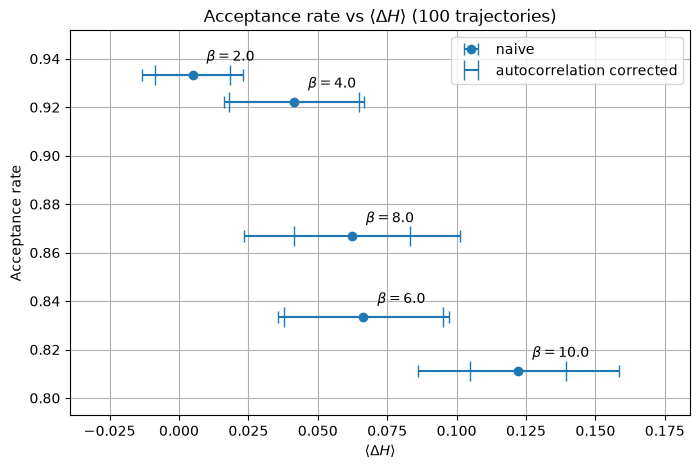

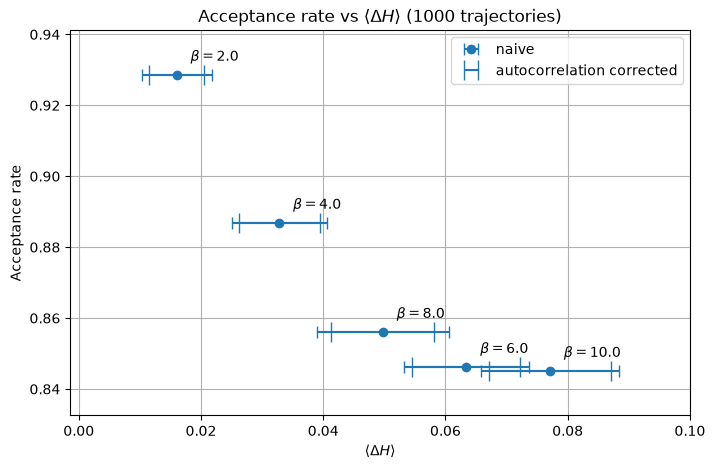

In [332]:
plot_acceptance_vs_dH(analysis_100, trajectories=100, compare_autocorr=True)
plot_acceptance_vs_dH(analysis_1000, trajectories=1000, compare_autocorr=True)

In [46]:
def exp_dH_stats(df):

    stats = (
        df
        .groupby("beta")
        .exp_minus_dH
        .agg(
            mean="mean",
            std="std",
            N="count"
        )
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats

In [47]:
exp_dH_100 = measurement_stats(df_dh_traj100, "exp_minus_dH", "beta")
exp_dH_1000 = measurement_stats(df_dh_traj1000, "exp_minus_dH", "beta")

exp_dH_mdsteps_100 = measurement_stats(df_dh_mdsteps_traj100, "exp_minus_dH", "mdsteps")
exp_dH_mdsteps_1000 = measurement_stats(df_dh_mdsteps_traj1000, "exp_minus_dH", "mdsteps")

exp_dH_trajL_100 = measurement_stats(df_dh_trajL_traj100, "exp_minus_dH", "trajL")
exp_dH_trajL_1000 = measurement_stats(df_dh_trajL_traj1000, "exp_minus_dH", "trajL")

In [48]:
def plot_exp_dH(df_stats, trajectories=None):

    plt.figure(figsize=(8,5))

    plt.errorbar(
        df_stats["beta"],
        df_stats["mean"],
        yerr=df_stats["sem"],
        fmt="o",
        capsize=4
    )

    plt.axhline(
        1,
        linestyle="--",
        label=r"$\langle e^{-\Delta H}\rangle=1$"
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel(r"$\langle e^{-\Delta H}\rangle$")

    if trajectories:
        plt.title(
            r"$\langle e^{-\Delta H}\rangle$ "
            f"({trajectories} trajectories)"
        )

    plt.grid()
    plt.legend()

    plt.show()

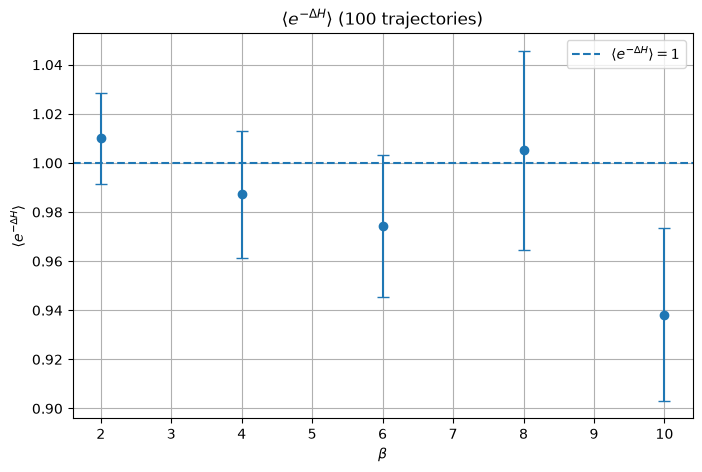

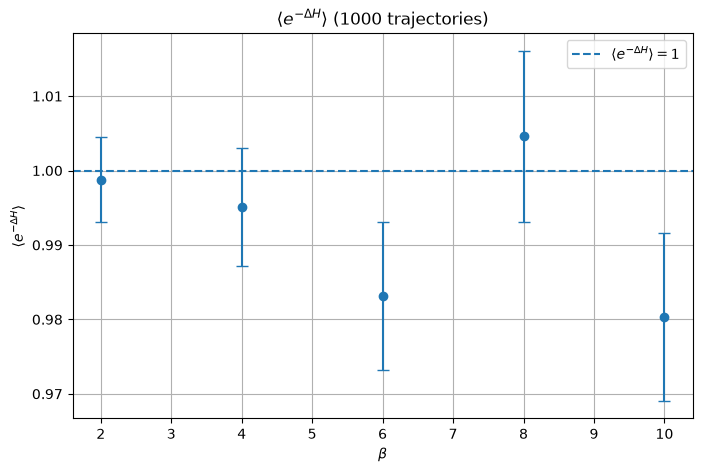

In [49]:
plot_exp_dH(exp_dH_100, trajectories=100)
plot_exp_dH(exp_dH_1000, trajectories=1000)

In [280]:
def plot_average_with_error(
    df,
    x,
    x_label,
    y_label,
    title=None,
    compare_autocorr=False,
):

    plt.figure(figsize=(7,5))

    # Naiver Fehler
    plt.errorbar(
        df[x],
        df["mean"],
        yerr=df["sem"],
        fmt="o",
        capsize=4,
        label="naive"
    )

    # Wolff-Fehler
    if compare_autocorr:
        plt.errorbar(
            df[x],
            df["mean"],
            yerr=df["sem_autocorr"],
            fmt="none",
            capsize=7,
            label="autocorrelation corrected"
        )
        plt.legend()

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    if title:
        plt.title(title)

    plt.grid()
    plt.show()

In [281]:
df_plaq_mdsteps_traj100["dtau"] = 1 / df_plaq_mdsteps_traj100["mdsteps"]
df_plaq_mdsteps_traj1000["dtau"] = 1 / df_plaq_mdsteps_traj1000["mdsteps"]

df_plaq_trajL_traj100["dtau"] = df_plaq_trajL_traj100["trajL"] /10
df_plaq_trajL_traj1000["dtau"] = df_plaq_trajL_traj1000["trajL"] /10

In [285]:
df_plaq_trajL_traj1000

,trajL,N,mean,std,sem,tau_int,W_opt,gamma0,sem_autocorr,dtau
0,0.50,910,0.501701,0.003672,0.000122,5.802616,41,0.000013,0.000414,0.050
1,1.00,910,0.501585,0.003472,0.000115,3.146330,23,0.000012,0.000289,0.100
2,1.25,910,0.501189,0.003659,0.000121,2.797759,21,0.000013,0.000287,0.125
3,2.00,910,0.501458,0.003568,0.000118,7.556836,51,0.000013,0.000460,0.200


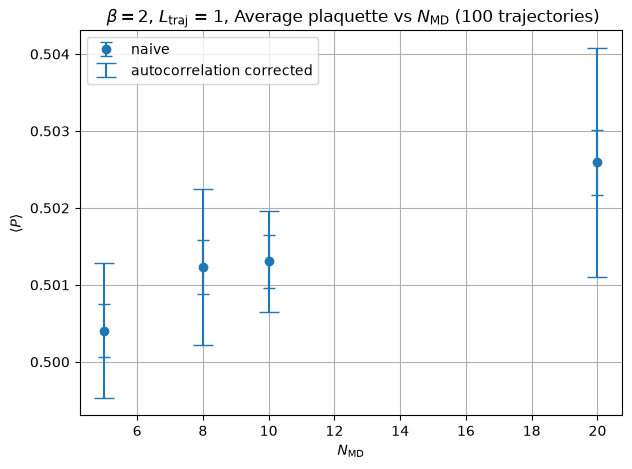

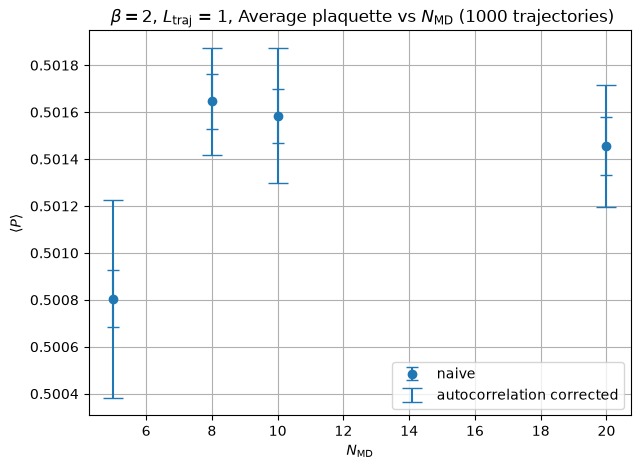

In [287]:
plot_average_with_error(
    df_plaq_mdsteps_traj100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, Average plaquette vs $N_{\mathrm{MD}}$ (100 trajectories)",
    compare_autocorr=True
)

plot_average_with_error(
    df_plaq_mdsteps_traj1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, Average plaquette vs $N_{\mathrm{MD}}$ (1000 trajectories)",
    compare_autocorr=True
)

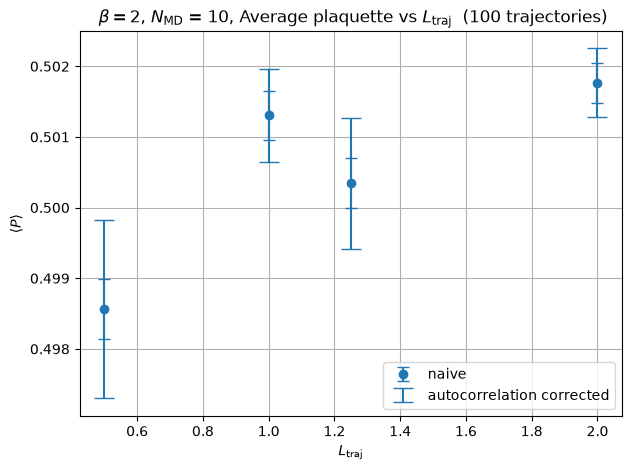

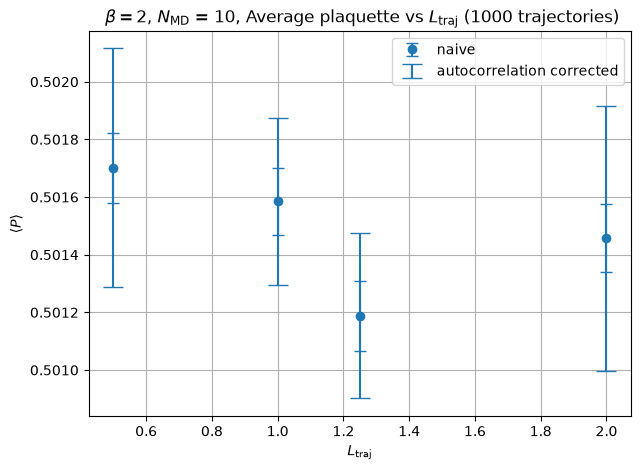

In [288]:
plot_average_with_error(
    df_plaq_trajL_traj100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, Average plaquette vs $L_{\mathrm{traj}}$  (100 trajectories)",
    compare_autocorr=True
)

plot_average_with_error(
    df_plaq_trajL_traj1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, Average plaquette vs $L_{\mathrm{traj}}$ (1000 trajectories)",
    compare_autocorr=True
)

In [55]:
dh_stats_mdsteps_traj100["dtau"] = 1 / dh_stats_mdsteps_traj100["mdsteps"]
dh_stats_mdsteps_traj1000["dtau"] = 1 / dh_stats_mdsteps_traj1000["mdsteps"]

dh_stats_trajL_traj100["dtau"] = dh_stats_trajL_traj100["trajL"] /10
dh_stats_trajL_traj1000["dtau"] = dh_stats_trajL_traj1000["trajL"] /10

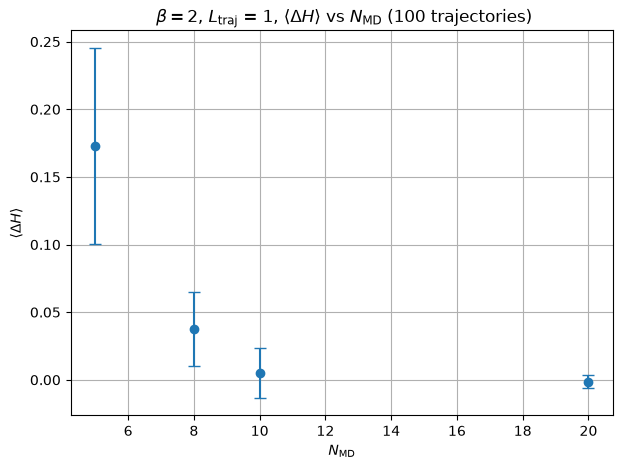

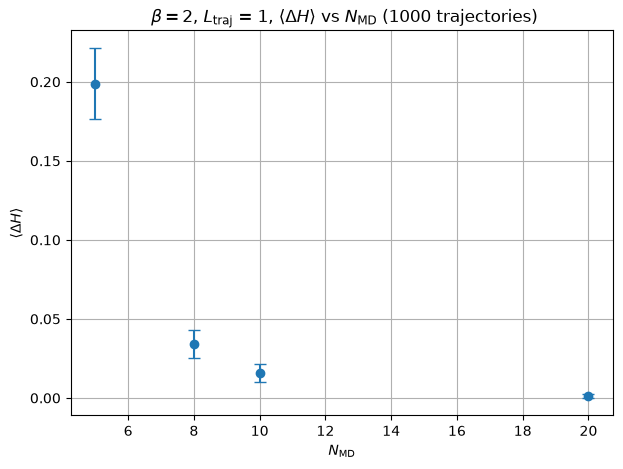

In [56]:
plot_average_with_error(
    dh_stats_mdsteps_traj100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \Delta H \rangle$ vs $N_{\mathrm{MD}}$ (100 trajectories)"
)

plot_average_with_error(
    dh_stats_mdsteps_traj1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \Delta H \rangle$ vs $N_{\mathrm{MD}}$ (1000 trajectories)"
)

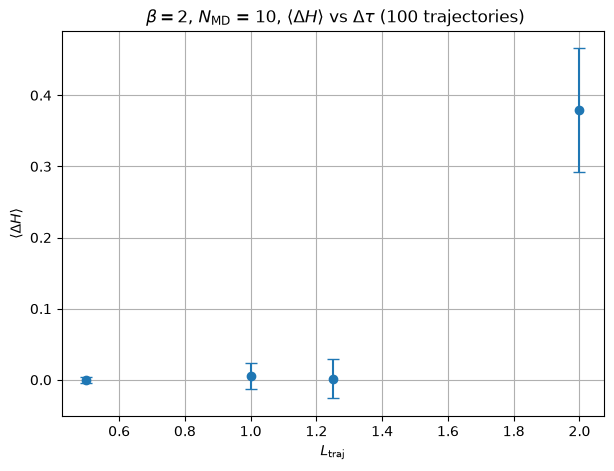

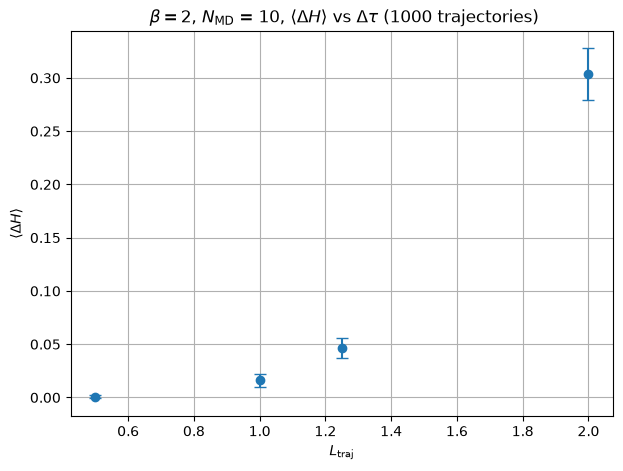

In [57]:
plot_average_with_error(
    dh_stats_trajL_traj100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \Delta H \rangle$ vs $\Delta \tau$ (100 trajectories)"
)

plot_average_with_error(
    dh_stats_trajL_traj1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \Delta H \rangle$ vs $\Delta \tau$ (1000 trajectories)"
)

In [58]:
exp_dH_mdsteps_100["dtau"] = 1 / exp_dH_mdsteps_100["mdsteps"]
exp_dH_mdsteps_1000["dtau"] = 1 / exp_dH_mdsteps_1000["mdsteps"]

exp_dH_trajL_100["dtau"] = exp_dH_trajL_100["trajL"] /10
exp_dH_trajL_1000["dtau"] = exp_dH_trajL_1000["trajL"] /10

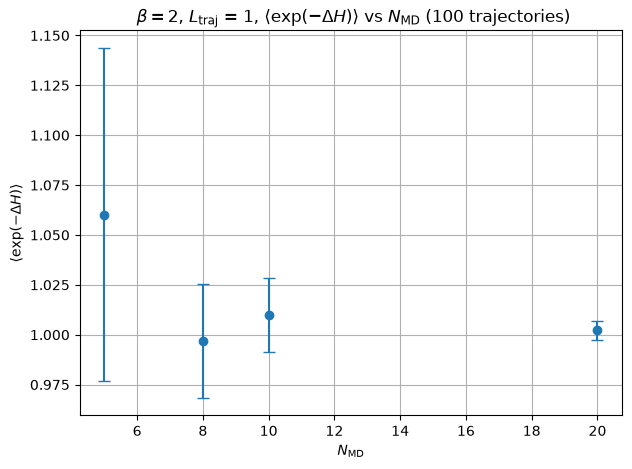

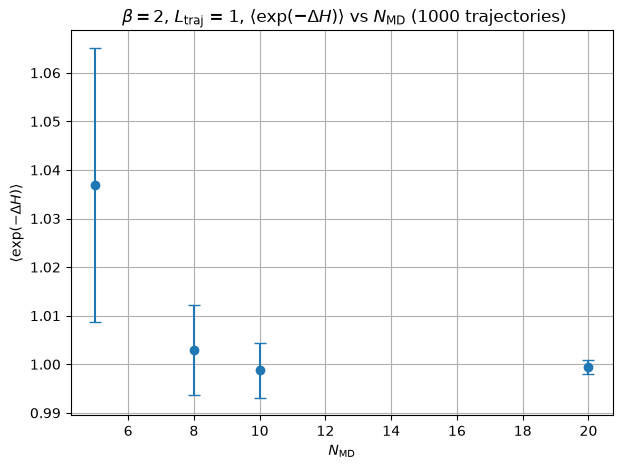

In [59]:
plot_average_with_error(
    exp_dH_mdsteps_100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \exp(-\Delta H) \rangle$ vs $N_{\mathrm{MD}}$ (100 trajectories)"
)

plot_average_with_error(
    exp_dH_mdsteps_1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \exp(-\Delta H) \rangle$ vs $N_{\mathrm{MD}}$ (1000 trajectories)"
)

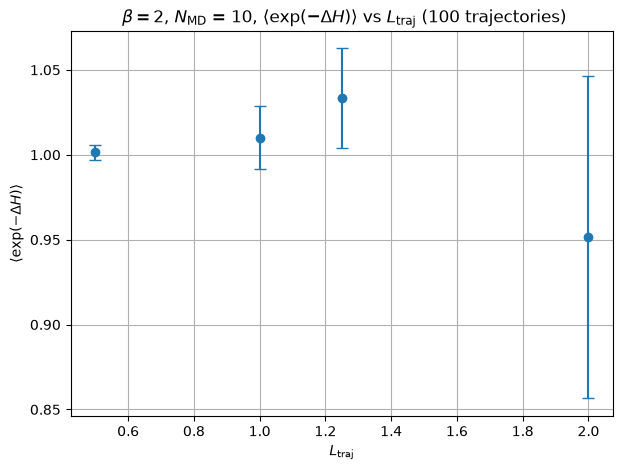

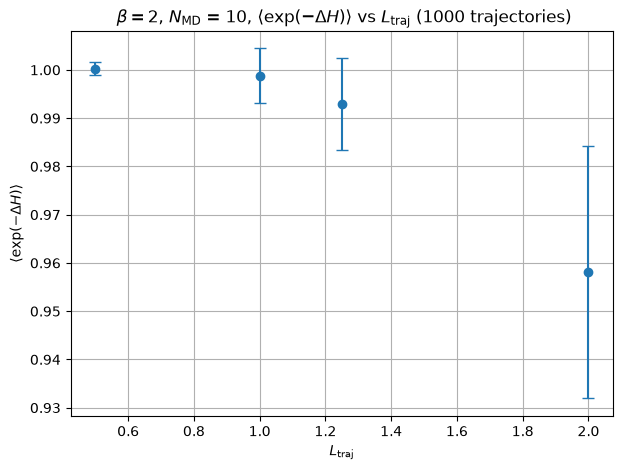

In [61]:
plot_average_with_error(
    exp_dH_trajL_100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \exp(-\Delta H) \rangle$ vs $L_{\mathrm{traj}}$ (100 trajectories)"
)

plot_average_with_error(
    exp_dH_trajL_1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \exp(-\Delta H) \rangle$ vs $L_{\mathrm{traj}}$ (1000 trajectories)"
)

In [296]:
from matplotlib.lines import Line2D


def plot_integrator_comparison(
    df_mdsteps,
    df_trajL,
    observable,
    trajectories=None,
    reference=None,
    compare_autocorr=False
):

    plt.figure(figsize=(8,5))

    color_md = "tab:blue"
    color_traj = "tab:orange"


    # ==========================
    # N_MD scan
    # ==========================

    # naive error
    plt.errorbar(
        df_mdsteps["dtau"],
        df_mdsteps["mean"],
        yerr=df_mdsteps["sem"],
        fmt="o",
        color=color_md,
        ecolor=color_md,
        capsize=3,
        capthick=1,
        elinewidth=1,
        alpha=0.8,
        label=r"varying $N_{\mathrm{MD}}$"
    )

    # autocorrelation error
    if compare_autocorr:
        plt.errorbar(
            df_mdsteps["dtau"],
            df_mdsteps["mean"],
            yerr=df_mdsteps["sem_autocorr"],
            fmt="none",
            ecolor=color_md,
            capsize=8,
            capthick=2,
            elinewidth=3,
            alpha=0.35
        )


    # ==========================
    # L_traj scan
    # ==========================

    plt.errorbar(
        df_trajL["dtau"],
        df_trajL["mean"],
        yerr=df_trajL["sem"],
        fmt="s",
        color=color_traj,
        ecolor=color_traj,
        capsize=3,
        capthick=1,
        elinewidth=1,
        alpha=0.8,
        label=r"varying $L_{\mathrm{traj}}$"
    )

    if compare_autocorr:
        plt.errorbar(
            df_trajL["dtau"],
            df_trajL["mean"],
            yerr=df_trajL["sem_autocorr"],
            fmt="none",
            ecolor=color_traj,
            capsize=8,
            capthick=2,
            elinewidth=3,
            alpha=0.35
        )


    if reference is not None:
        plt.axhline(
            reference,
            color="black",
            linestyle=":",
            linewidth=1
        )


    # ==========================
    # legend
    # ==========================

    handles, labels = plt.gca().get_legend_handles_labels()

    if compare_autocorr:
        handles.extend([
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=1,
                label="naive error"
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=3,
                alpha=0.35,
                label="autocorrelation corrected"
            )
        ])

    plt.legend(handles=handles)


    plt.xlabel(r"$\Delta\tau=L_{\rm traj}/N_{\rm MD}$")
    plt.ylabel(observable)

    if trajectories is not None:
        plt.title(
            f"{observable} vs $\\Delta\\tau$ "
            f"({trajectories} trajectories)"
        )
    else:
        plt.title(
            f"{observable} vs $\\Delta\\tau$"
        )

    plt.grid()
    plt.show()

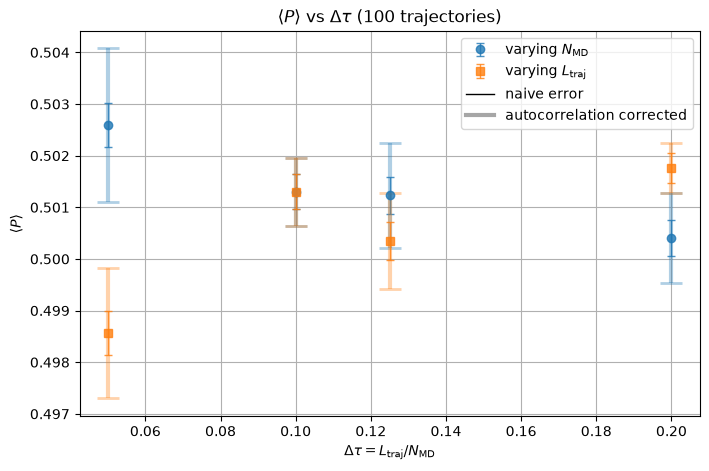

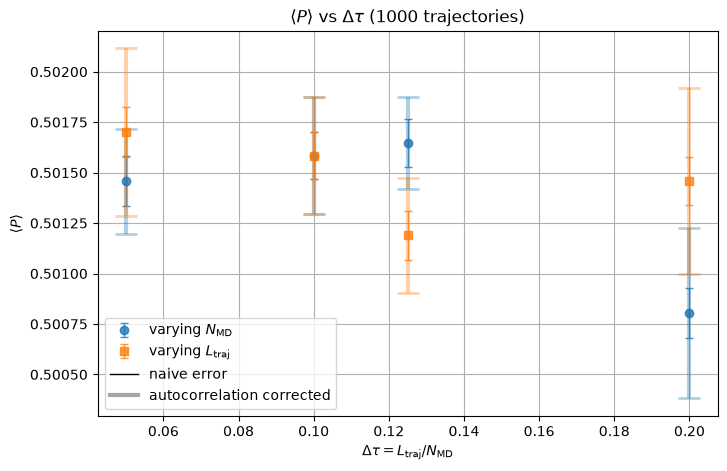

In [297]:
plot_integrator_comparison(
    df_plaq_mdsteps_traj100,
    df_plaq_trajL_traj100,
    observable=r"$\langle P\rangle$",
    trajectories=100,
    compare_autocorr=True
)

plot_integrator_comparison(
    df_plaq_mdsteps_traj1000,
    df_plaq_trajL_traj1000,
    observable=r"$\langle P\rangle$",
    trajectories=1000,
    compare_autocorr=True
)

In [333]:
plot_integrator_comparison(
    dh_stats_mdsteps_traj100,
    dh_stats_trajL_traj100,
    observable=r"$\langle \Delta H\rangle$",
    trajectories=100,
    compare_autocorr=True
)

plot_integrator_comparison(
    dh_stats_mdsteps_traj1000,
    dh_stats_trajL_traj1000,
    observable=r"$\langle \Delta H\rangle$",
    trajectories=1000,
    compare_autocorr=True
)

KeyError: 'dtau'

<Figure size 800x500 with 0 Axes>

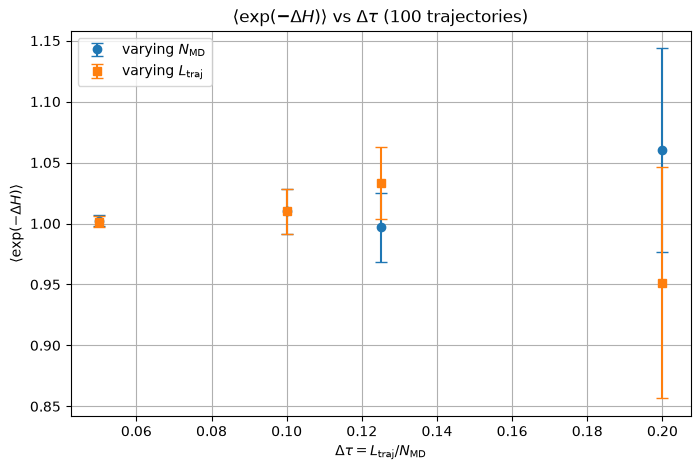

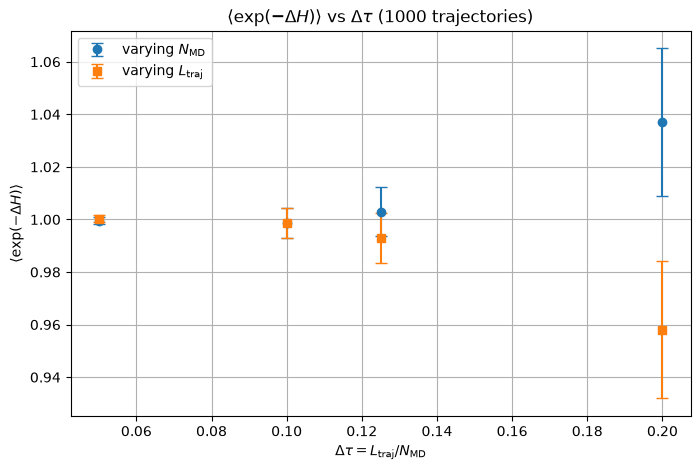

In [120]:
plot_integrator_comparison(
    exp_dH_mdsteps_100,
    exp_dH_trajL_100,
    observable=r"$\langle \exp(-\Delta H)\rangle$",
    trajectories=100
)

plot_integrator_comparison(
    exp_dH_mdsteps_1000,
    exp_dH_trajL_1000,
    observable=r"$\langle \exp(-\Delta H) \rangle$",
    trajectories=1000
)

In [ ]:
#statsmodels.tsa.stattools.acf(x, adjusted=False, nlags=None, qstat=False, fft=True, alpha=None, bartlett_confint=True, missing='none')
# x=verwendete werte
# adjusted = normiere mit n oder n-k, k ist die differnz zwischen den zeitpunkten t_1 und t_2
# nlags = abstand bis zu dem werte verglichen werden
# qstat = irgendwas mit statisitk
# fft =acf durch fast fourier trafo (fft)
# alpha = gibt konfidenzintervall zurück, verwendet bartlett
# bartlett = art die standardabweichung zu berechnen
#missing = gibt an wie NaN behandelt werden 


In [121]:
def parse_topology(log):

    data = []

    with open(log) as f:
        for line in f:

            m = re.search(
                r"Topological Charge:\s*\[\s*(\d+)\s*\]\s*([-0-9.eE+]+)",
                line
            )

            if m:
                data.append({
                    "trajectory": int(m.group(1)),
                    "Q": float(m.group(2))
                })

    return pd.DataFrame(data)

In [124]:
q_measurements = []

for log in logs:

    q = parse_topology(log)

    params = parse_log_name(log)

    for key, value in params.items():
        q[key] = value

    q["file"] = log.name

    q_measurements.append(q)

df_q = pd.concat(q_measurements, ignore_index=True)

In [125]:
df_q_traj100 = df_q[
    (df_q.trajectories == 100) &
    (df_q.trajectory > 20)
]

df_q_traj1000 = df_q[
    (df_q.trajectories == 1000) &
    (df_q.trajectory > 100)
]

In [123]:
def plot_topology_history(df, beta=None, trajectories=None):

    plt.figure(figsize=(8,5))

    if beta is None:

        # Alle beta plotten
        for b in sorted(df.beta.unique()):

            subset = (
                df[df.beta == b]
                .sort_values("trajectory")
            )

            plt.plot(
                subset.trajectory,
                subset.Q,
                ".-",
                label=fr"$\beta={b}$"
            )

        title = "Topological charge"

        plt.legend()

    else:

        # Nur ein beta plotten
        subset = (
            df[df.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.Q,
            ".-"
        )

        title = fr"Topological charge ($\beta={beta}$)"


    if trajectories is not None:
        title += f" ({trajectories} trajectories)"

    plt.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Trajectory")
    plt.ylabel(r"$Q$")
    plt.title(title)

    plt.grid()

    plt.show()

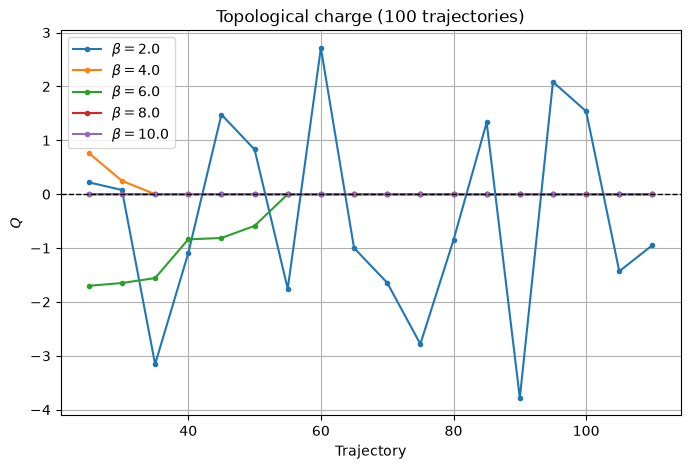

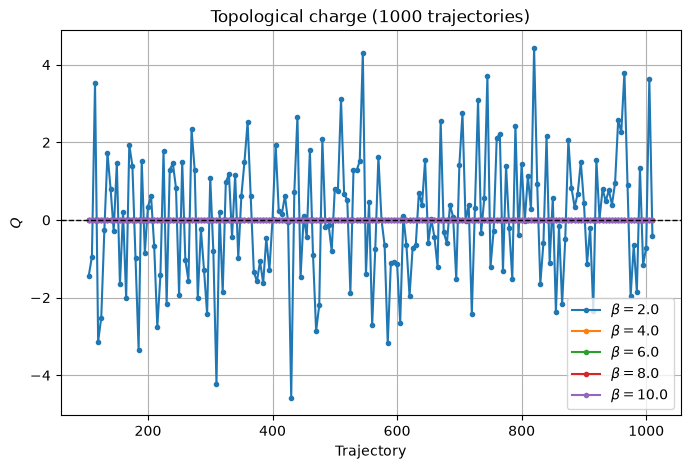

In [126]:
plot_topology_history(
    df_q_traj100,
    trajectories=100
)
plot_topology_history(
    df_q_traj1000,
    trajectories=1000
)

In [44]:
logfile = log_dir / "L8x8x8x8_beta6_md10_trajL1.0_traj100_ckpt5.log"

q = parse_topology(logfile)

q[:5]

[{'trajectory': 5, 'Q': -1.401114057529427},
 {'trajectory': 10, 'Q': -2.317731446012111},
 {'trajectory': 15, 'Q': -1.741037926784045},
 {'trajectory': 20, 'Q': -1.733078285691357},
 {'trajectory': 25, 'Q': -1.701356116330909}]

In [45]:
top_measurements = []

for log in logs:

    params = parse_log_name(log)

    qs = parse_topology(log)

    for q in qs:
        q.update(params)
        q["file"] = log.name
        top_measurements.append(q)


qdf = pd.DataFrame(top_measurements)

qdf.head()

,trajectory,Q,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,5,0.800794,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
1,10,-0.148791,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
2,15,0.848236,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
3,20,0.824696,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
4,25,0.763690,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log


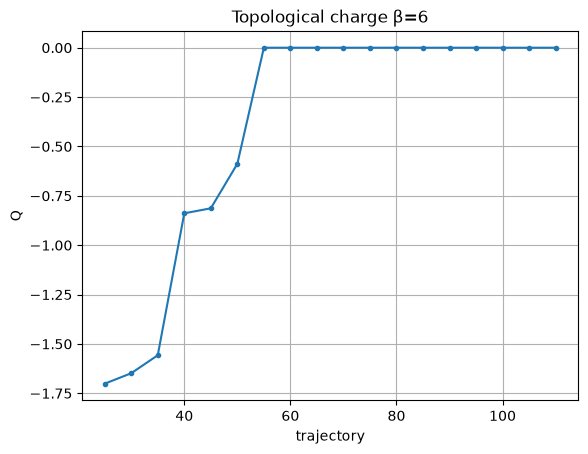

In [46]:
subset = qdf[
    (qdf.beta == 6) &
    (qdf.trajectory > 20)
].sort_values("trajectory")

plt.plot(
    subset.trajectory,
    subset.Q,
    ".-"
)

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.title("Topological charge β=6")
plt.grid()
plt.show()

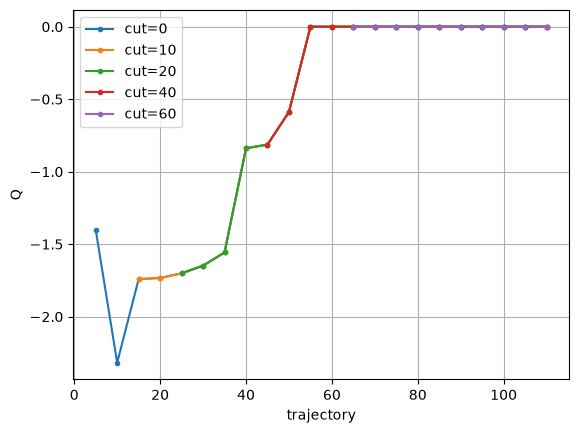

In [47]:
for cut in [0,10,20,40,60]:

    subset = qdf[
        (qdf.beta == 6) &
        (qdf.trajectory > cut)
    ].sort_values("trajectory")

    plt.plot(
        subset.trajectory,
        subset.Q,
        ".-",
        label=f"cut={cut}"
    )

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.legend()
plt.grid()
plt.show()

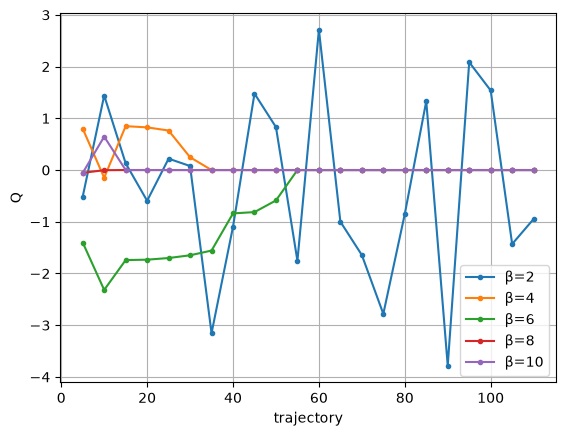

In [48]:
for beta in [2,4,6,8,10]:

    subset = qdf[
        (qdf.beta == beta)
    ].sort_values("trajectory")

    plt.plot(
        subset.trajectory,
        subset.Q,
        ".-",
        label=f"β={beta}"
    )

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.legend()
plt.grid()
plt.show()

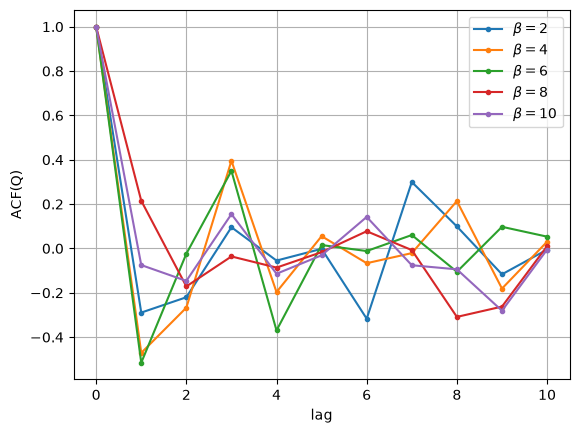

In [52]:
from statsmodels.tsa.stattools import acf

for beta in [2,4,6,8,10]:

    subset = qdf[
        (qdf.beta == beta) &
        (qdf.trajectory > 50)
    ].sort_values("trajectory")

    Q = subset.Q.values

    ac = acf(Q, nlags=10)

    plt.plot(ac, ".-", label=f"$\\beta={beta}$")

plt.xlabel("lag")
plt.ylabel("ACF(Q)")
plt.legend()
plt.grid()
plt.show()